# **mobility_package — Seattle Bird (Dockless) Example Run**

This notebook runs the complete fairness analysis pipeline for Seattle's
Bird dockless bike-share system using one day of GBFS snapshot data.

**Key difference from docked systems:**
Dockless systems have no fixed stations. Usage is inferred from consecutive
5-minute location snapshots — no separate trip CSV is needed. Capacity is
estimated from the peak-availability snapshot across the day.

**Pipeline overview:**
1. Load Context → parse snapshot file, geocode pings to census blocks
2. Compute Metrics → availability, capacity, usage, idle time, safety
3. Fairness Calculation → Gini + Alpha fairness per metric
4. Choropleth Maps → one map per metric
5. Correlation Maps → pairwise metric comparisons
6. Scatter Plot → supply vs demand classification
7. Fairness Trend → time-series fairness (requires 7 days)
8. Summary Table → paper-style fairness table

## Cell 0 — Imports
Run this first. If any import fails, check that `mobility_package` is
in the same directory as this notebook or is installed in your environment.

In [2]:
# ============================================================
# Cell 0 — Imports
# ============================================================
from pathlib import Path
from mobility_package import (
    dockless_wrapper,
    fairness_calculation,
    map_visual,
    correlation_visual,
    scatter_visual,
    trend_visual,
    table_visual,
)
print("All modules loaded successfully.")

All modules loaded successfully.


## Cell 1 — File Paths

**This is the only cell you need to edit.**
Update the filenames to match what is inside your `SEATTLE_BIRD_ASSETS` folder.
Every other cell reads from these variables — nothing else needs to change.

Expected folder structure:

SEATTLE_BIRD_ASSETS/

seattle_bird_freebike_status.txt

tl_2024_53_tabblock20.shp    (+ .dbf .prj .shx)

tl_2024_53_tract.shp         (+ .dbf .prj .shx)

Seattle_Streets.shp          (+ .dbf .prj .shx)

SDOT_Bike_Facilities.geojson

Planned_Bike_Facilities.shp  (+ .dbf .prj .shx)

All outputs will be saved inside `SEATTLE_BIRD_ASSETS/SEATTLE_BIRD_OUTPUT/`.

**Note on the tag:** All dockless output filenames are tagged with the
vendor name `seattle_bird` — for example `availability_norm_hourly_tract_seattle_bird.csv`.
The `SEA_TAG` variable below is used everywhere so you only need to set it once.

In [3]:
# ============================================================
# Cell 1 — File Paths (edit only this cell)
# ============================================================

SEA_ASSETS = Path("SEATTLE_BIRD_ASSETS")

SEA_STATUS          = SEA_ASSETS / "seattle_bird_dkless_freebike_status_6_9.txt"
SEA_BLOCKS_SHP      = SEA_ASSETS / "tl_2024_53_tabblock20.shp"
SEA_TRACT_SHP       = SEA_ASSETS / "tl_2024_53_tract.shp"
SEA_STREETS_SHP     = SEA_ASSETS / "Seattle_Streets.shp"
SEA_BIKE_LANES      = SEA_ASSETS / "SDOT_Bike_Facilities_5512142703833213564.geojson"
SEA_PLANNED_LANES   = SEA_ASSETS / "Planned_Bike_Facilities.shp"

SEA_OUT      = "SEATTLE_BIRD_ASSETS/SEATTLE_BIRD_OUTPUT"
SEA_FAIR_DIR = "SEATTLE_BIRD_ASSETS/SEATTLE_BIRD_OUTPUT/FAIRNESS_RESULTS"

# Date window — must match the date of your snapshot file
SEA_START = "2025-06-09 00:00:00"
SEA_END   = "2025-06-09 23:59:59"

# Vendor tag — appears in every output filename produced by the dockless wrapper
SEA_TAG = "seattle_bird"

print("Paths configured.")
print(f"  Snapshot file : {SEA_STATUS}")
print(f"  Output dir    : {SEA_OUT}")
print(f"  Vendor tag    : {SEA_TAG}")

Paths configured.
  Snapshot file : SEATTLE_BIRD_ASSETS\seattle_bird_dkless_freebike_status_6_9.txt
  Output dir    : SEATTLE_BIRD_ASSETS/SEATTLE_BIRD_OUTPUT
  Vendor tag    : seattle_bird


## Cell 2 — Load Context

Parses the raw GBFS free-bike-status snapshot file, spatially joins every
ping to a census block using the Seattle census blocks shapefile, derives
the census tract from the block ID, applies the time window filter, and
builds the shared `ctx` dictionary used by every downstream compute function.

Asset paths are passed as explicit overrides here so the notebook works
from the local `SEATTLE_BIRD_ASSETS/` folder without needing to edit
any paths inside the package itself.

This cell must always run before any Cell 3 metric functions.

In [4]:
# ============================================================
# Cell 2 — Load Context
# ============================================================
sea_ctx = dockless_wrapper.load_dockless_context(
    system_key          = "SEATTLE_BIRD_DOCKLESS",
    freebike_status_txt = SEA_STATUS,
    output_dir          = SEA_OUT,
    time_start          = SEA_START,
    time_end            = SEA_END,

    # Asset path overrides — point to the local SEATTLE_BIRD_ASSETS/ folder.
    # These override the hardcoded paths inside _SYSTEMS["SEATTLE_BIRD_DOCKLESS"].
    census_blocks_shp       = SEA_BLOCKS_SHP,
    centerline_streets_path = SEA_STREETS_SHP,
    bike_lanes_path         = SEA_BIKE_LANES,
    planned_bike_lanes_path = SEA_PLANNED_LANES,
    centroid_tract_path     = SEA_TRACT_SHP,
)

[SEATTLE_BIRD_DOCKLESS] Parsing snapshot file: SEATTLE_BIRD_ASSETS\seattle_bird_dkless_freebike_status_6_9.txt
[SEATTLE_BIRD_DOCKLESS] Spatially joining pings to census blocks...


Census API geocode: 100%|██████████| 2/2 [00:02<00:00,  1.20s/it]


[SEATTLE_BIRD_DOCKLESS] Context ready. Rows: 722,686  |  Tracts: 127


## Cell 3 — Compute Metrics

Computes all five utility metrics and saves one CSV per metric to
`SEATTLE_BIRD_OUTPUT/`. All filenames include the vendor tag `seattle_bird`.

**No trip CSV is needed.** Usage is inferred from consecutive 5-minute
location snapshots — a vehicle disappearing from a location is counted
as a trip start, a reappearance is a trip end.

**Option A** runs everything in one call.
**Option B** lets you run individual metrics — useful if you only need
one or two, or if one metric fails and you want to re-run it alone.

Files saved to `SEATTLE_BIRD_OUTPUT/`:

| File | Metric |
|---|---|
| `availability_norm_hourly_tract_seattle_bird.csv` | Availability |
| `capacity_tract_seattle_bird.csv` | Capacity |
| `usage_norm_hourly_tract_seattle_bird.csv` | Usage |
| `idle_norm_hourly_tract_seattle_bird.csv` | Idle Time |
| `safety_tract_seattle_bird.csv` | Safety |

In [5]:
# ============================================================
# Cell 3 — Compute Metrics
# ============================================================

# ── OPTION A — All metrics at once ───────────────────────────
sea_results = dockless_wrapper.compute_all(sea_ctx)

# ── OPTION B — Individual metrics ────────────────────────────
# Uncomment only the metrics you need and comment out compute_all above.

# Availability — non-reserved, non-disabled vehicles per tract per hour
# avail = dockless_wrapper.compute_availability(sea_ctx)

# Capacity — peak-snapshot vehicle count per tract (proxy for fleet size)
# cap = dockless_wrapper.compute_capacity(sea_ctx)

# Usage — inferred trip starts and ends per tract per hour (no trip CSV needed)
# usage = dockless_wrapper.compute_usage(sea_ctx)

# Idle Time — ping count × 5 minutes per vehicle per tract per hour
# idle = dockless_wrapper.compute_idle_time(sea_ctx)

# Safety — bike lane and protected lane ratio per tract
# safe = dockless_wrapper.compute_safety(sea_ctx)


[SEATTLE_BIRD_DOCKLESS] Running compute_all...


d:\Research Fellowship\Mobility_Package_Code\mobility_package\dockless_wrapper.py:470: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  av["h_slot"] = av["timestamp"].dt.floor(tract_time_granularity)


  [availability] Done. Tract rows: 2,900
  [capacity] Peak availability slot: 2025-06-09 03:05:00  (system total: 5,073 pings)
  [capacity] Done. Tracts with capacity: 119  |  Max capacity: 455
  [usage] Done. Tract rows: 3,070
  [idle_time] Done. Tract rows: 4,450
  [safety] Done. Tracts: 1,784
[SEATTLE_BIRD_DOCKLESS] All metrics complete. Outputs in: SEATTLE_BIRD_ASSETS\SEATTLE_BIRD_OUTPUT


## Cell 4 — Fairness Calculation

Reads the CSVs saved by Cell 3 and computes two fairness metrics for
every utility:

- **Gini Coefficient** — 0 = perfectly equal, 1 = perfectly unequal
- **Alpha Fairness (α = 1)** — sum of log(x+1) across all tracts,
  higher = more total utility delivered fairly

`filter_to_capacity_service_area = False` for dockless systems — there
are no fixed stations so there is no hard service area boundary. All
tracts where vehicles were observed are included.

Results are saved to `SEATTLE_BIRD_OUTPUT/FAIRNESS_RESULTS/`.

In [6]:
# ============================================================
# Cell 4 — Fairness Calculation
# ============================================================
sea_fairness = fairness_calculation.run_paper_style_fairness(
    city_key       = "SEATTLE_BIRD_DOCKLESS",
    save_directory = SEA_FAIR_DIR,

    capacity_csv     = f"{SEA_OUT}/capacity_tract_{SEA_TAG}.csv",
    availability_csv = f"{SEA_OUT}/availability_norm_hourly_tract_{SEA_TAG}.csv",
    safety_csv       = f"{SEA_OUT}/safety_tract_{SEA_TAG}.csv",
    usage_csv        = f"{SEA_OUT}/usage_norm_hourly_tract_{SEA_TAG}.csv",
    idle_time_csv    = f"{SEA_OUT}/idle_norm_hourly_tract_{SEA_TAG}.csv",

    # False for dockless — no fixed stations means no hard service area
    filter_to_capacity_service_area = False,
)

display(sea_fairness["fairness_table"])
print("Saved to:", sea_fairness["saved_to"])

  [fairness] Capacity: Vehicle capacity → 'vehicle_capacity'
  [fairness] Safety: Bike lane ratio → 'bike_lane_ratio', Protected bike lane ratio → 'protected_bike_lane_ratio'
  [fairness] Availability: Total vehicles available → 'total_available'
  [fairness] Idle Time: Average idle time → 'avg_idle_time_minutes'
  [fairness] Usage: Trips starting → 'starts', Trips ending → 'ends'


,Utility,Metric,Min,Max,Mean,StDev,Gini Coefficient,"Alpha Fairness (α = 1, Normalized)"
0,Capacity,Vehicle capacity,2.000000,455.000000,42.974576,70.256728,0.701858,9.283356
1,Safety,Bike lane ratio,0.000000,1.003807,0.033365,0.109838,0.922341,50.260370
2,Safety,Protected bike lane ratio,0.000000,0.562494,0.006002,0.034067,0.968004,16.508589
3,Availability,Total vehicles available,7.000000,2449.708333,238.371187,396.705675,0.683034,8.901607
4,Idle Time,Average idle time,35.000000,6152.604167,651.063358,979.450276,0.660212,11.043776
5,Usage,Trips starting,0.142857,919.520000,70.790481,129.178291,0.706369,8.497202
6,Usage,Trips ending,0.142857,919.520000,70.790481,129.178291,0.706369,8.497202


Saved to: SEATTLE_BIRD_ASSETS\SEATTLE_BIRD_OUTPUT\FAIRNESS_RESULTS\SEATTLE_BIRD_DOCKLESS_fairness_results.csv


## Cell 5 — Choropleth Maps

Produces one choropleth PNG per metric showing how each utility is
distributed across Seattle census tracts.

**Option A** produces all four maps in one call.
**Option B** produces one map at a time — useful if you only need a
specific metric or want to re-run one map with different settings.

Files saved to `SEATTLE_BIRD_OUTPUT/MAPS/`:

| File | Metric |
|---|---|
| `availability_rank__mean.png` | Availability |
| `usage_rank__mean.png` | Usage |
| `idle_time_rank__mean.png` | Idle Time |
| `safety_rank__mean.png` | Safety |

In [7]:
# ============================================================
# Cell 5 — Choropleth Maps
# ============================================================

# ── OPTION A — All four maps at once ─────────────────────────
map_visual.plot_all(
    availability_csv = f"{SEA_OUT}/availability_norm_hourly_tract_{SEA_TAG}.csv",
    usage_csv        = f"{SEA_OUT}/usage_norm_hourly_tract_{SEA_TAG}.csv",
    idle_time_csv    = f"{SEA_OUT}/idle_norm_hourly_tract_{SEA_TAG}.csv",
    safety_csv       = f"{SEA_OUT}/safety_tract_{SEA_TAG}.csv",
    capacity_csv     = f"{SEA_OUT}/capacity_tract_{SEA_TAG}.csv",
    tract_shp        = SEA_TRACT_SHP,
    output_dir       = f"{SEA_OUT}/MAPS",
)

# ── OPTION B — One map at a time ─────────────────────────────
# Uncomment whichever map you want and comment out plot_all above.

# Availability map → availability_rank__mean.png
# map_visual.plot_map(
#     metric       = "availability",
#     csv          = f"{SEA_OUT}/availability_norm_hourly_tract_{SEA_TAG}.csv",
#     capacity_csv = f"{SEA_OUT}/capacity_tract_{SEA_TAG}.csv",
#     tract_shp    = SEA_TRACT_SHP,
#     output_dir   = f"{SEA_OUT}/MAPS",
# )

# Usage map → usage_rank__mean.png
# map_visual.plot_map(
#     metric       = "usage",
#     csv          = f"{SEA_OUT}/usage_norm_hourly_tract_{SEA_TAG}.csv",
#     capacity_csv = f"{SEA_OUT}/capacity_tract_{SEA_TAG}.csv",
#     tract_shp    = SEA_TRACT_SHP,
#     output_dir   = f"{SEA_OUT}/MAPS",
# )

# Idle time map → idle_time_rank__mean.png
# map_visual.plot_map(
#     metric       = "idle_time",
#     csv          = f"{SEA_OUT}/idle_norm_hourly_tract_{SEA_TAG}.csv",
#     capacity_csv = f"{SEA_OUT}/capacity_tract_{SEA_TAG}.csv",
#     tract_shp    = SEA_TRACT_SHP,
#     output_dir   = f"{SEA_OUT}/MAPS",
# )

# Safety map → safety_rank__mean.png
# map_visual.plot_map(
#     metric       = "safety",
#     csv          = f"{SEA_OUT}/safety_tract_{SEA_TAG}.csv",
#     capacity_csv = f"{SEA_OUT}/capacity_tract_{SEA_TAG}.csv",
#     tract_shp    = SEA_TRACT_SHP,
#     output_dir   = f"{SEA_OUT}/MAPS",
# )

Plotting availability map...
   -> value_col 'total_vehicle_available_norm' not found. Auto-selected 'total_available_norm' for availability.
   -> Saved: SEATTLE_BIRD_ASSETS\SEATTLE_BIRD_OUTPUT\MAPS\availability_rank__mean.png
Plotting usage map...
   -> Saved: SEATTLE_BIRD_ASSETS\SEATTLE_BIRD_OUTPUT\MAPS\usage_rank__mean.png
Plotting idle_time map...
   -> Saved: SEATTLE_BIRD_ASSETS\SEATTLE_BIRD_OUTPUT\MAPS\idle_time_rank__mean.png
Plotting safety map...
   -> Saved: SEATTLE_BIRD_ASSETS\SEATTLE_BIRD_OUTPUT\MAPS\safety_rank__mean.png


{'availability': WindowsPath('SEATTLE_BIRD_ASSETS/SEATTLE_BIRD_OUTPUT/MAPS/availability_rank__mean.png'),
 'usage': WindowsPath('SEATTLE_BIRD_ASSETS/SEATTLE_BIRD_OUTPUT/MAPS/usage_rank__mean.png'),
 'idle_time': WindowsPath('SEATTLE_BIRD_ASSETS/SEATTLE_BIRD_OUTPUT/MAPS/idle_time_rank__mean.png'),
 'safety': WindowsPath('SEATTLE_BIRD_ASSETS/SEATTLE_BIRD_OUTPUT/MAPS/safety_rank__mean.png')}

## Cell 6 — Correlation Maps

Compares every pair of metrics side by side on a map. Each tract is
colored based on whether it is high or low on both metrics:

| Color | Meaning |
|---|---|
| Dark blue | High on both metrics |
| Light blue | High X, Low Y |
| Light orange | Low X, High Y |
| Dark orange | Low on both metrics |

All six pairwise combinations are run automatically. One PNG per pair
is saved to `SEATTLE_BIRD_OUTPUT/CORRELATION_MAPS/`.

To run only a specific pair, comment out the loop and uncomment the
single call at the bottom.

In [8]:
# ============================================================
# Cell 6 — Correlation Maps
# ============================================================

SEA_CAP = f"{SEA_OUT}/capacity_tract_{SEA_TAG}.csv"

# ── OPTION A — All six pairs at once ─────────────────────────
pairs = [
    ("availability", f"{SEA_OUT}/availability_norm_hourly_tract_{SEA_TAG}.csv", "usage",     f"{SEA_OUT}/usage_norm_hourly_tract_{SEA_TAG}.csv"),
    ("availability", f"{SEA_OUT}/availability_norm_hourly_tract_{SEA_TAG}.csv", "idle_time", f"{SEA_OUT}/idle_norm_hourly_tract_{SEA_TAG}.csv"),
    ("availability", f"{SEA_OUT}/availability_norm_hourly_tract_{SEA_TAG}.csv", "safety",    f"{SEA_OUT}/safety_tract_{SEA_TAG}.csv"),
    ("usage",        f"{SEA_OUT}/usage_norm_hourly_tract_{SEA_TAG}.csv",        "idle_time", f"{SEA_OUT}/idle_norm_hourly_tract_{SEA_TAG}.csv"),
    ("usage",        f"{SEA_OUT}/usage_norm_hourly_tract_{SEA_TAG}.csv",        "safety",    f"{SEA_OUT}/safety_tract_{SEA_TAG}.csv"),
    ("idle_time",    f"{SEA_OUT}/idle_norm_hourly_tract_{SEA_TAG}.csv",         "safety",    f"{SEA_OUT}/safety_tract_{SEA_TAG}.csv"),
]

for mx, cx, my, cy in pairs:
    correlation_visual.plot_correlation(
        metric_x     = mx,
        csv_x        = cx,
        metric_y     = my,
        csv_y        = cy,
        capacity_csv = SEA_CAP,
        tract_shp    = SEA_TRACT_SHP,
        output_dir   = f"{SEA_OUT}/CORRELATION_MAPS",
    )

# ── OPTION B — One pair at a time ────────────────────────────
# Comment out the loop above and uncomment one block below.

# Availability vs Usage → correlation_availability_vs_usage__mean__quantile.png
# correlation_visual.plot_correlation(
#     metric_x     = "availability",
#     csv_x        = f"{SEA_OUT}/availability_norm_hourly_tract_{SEA_TAG}.csv",
#     metric_y     = "usage",
#     csv_y        = f"{SEA_OUT}/usage_norm_hourly_tract_{SEA_TAG}.csv",
#     capacity_csv = SEA_CAP,
#     tract_shp    = SEA_TRACT_SHP,
#     output_dir   = f"{SEA_OUT}/CORRELATION_MAPS",
# )

# Availability vs Idle Time → correlation_availability_vs_idle_time__mean__quantile.png
# correlation_visual.plot_correlation(
#     metric_x     = "availability",
#     csv_x        = f"{SEA_OUT}/availability_norm_hourly_tract_{SEA_TAG}.csv",
#     metric_y     = "idle_time",
#     csv_y        = f"{SEA_OUT}/idle_norm_hourly_tract_{SEA_TAG}.csv",
#     capacity_csv = SEA_CAP,
#     tract_shp    = SEA_TRACT_SHP,
#     output_dir   = f"{SEA_OUT}/CORRELATION_MAPS",
# )

# Availability vs Safety → correlation_availability_vs_safety__mean__quantile.png
# correlation_visual.plot_correlation(
#     metric_x     = "availability",
#     csv_x        = f"{SEA_OUT}/availability_norm_hourly_tract_{SEA_TAG}.csv",
#     metric_y     = "safety",
#     csv_y        = f"{SEA_OUT}/safety_tract_{SEA_TAG}.csv",
#     capacity_csv = SEA_CAP,
#     tract_shp    = SEA_TRACT_SHP,
#     output_dir   = f"{SEA_OUT}/CORRELATION_MAPS",
# )

# Usage vs Idle Time → correlation_usage_vs_idle_time__mean__quantile.png
# correlation_visual.plot_correlation(
#     metric_x     = "usage",
#     csv_x        = f"{SEA_OUT}/usage_norm_hourly_tract_{SEA_TAG}.csv",
#     metric_y     = "idle_time",
#     csv_y        = f"{SEA_OUT}/idle_norm_hourly_tract_{SEA_TAG}.csv",
#     capacity_csv = SEA_CAP,
#     tract_shp    = SEA_TRACT_SHP,
#     output_dir   = f"{SEA_OUT}/CORRELATION_MAPS",
# )

# Usage vs Safety → correlation_usage_vs_safety__mean__quantile.png
# correlation_visual.plot_correlation(
#     metric_x     = "usage",
#     csv_x        = f"{SEA_OUT}/usage_norm_hourly_tract_{SEA_TAG}.csv",
#     metric_y     = "safety",
#     csv_y        = f"{SEA_OUT}/safety_tract_{SEA_TAG}.csv",
#     capacity_csv = SEA_CAP,
#     tract_shp    = SEA_TRACT_SHP,
#     output_dir   = f"{SEA_OUT}/CORRELATION_MAPS",
# )

# Idle Time vs Safety → correlation_idle_time_vs_safety__mean__quantile.png
# correlation_visual.plot_correlation(
#     metric_x     = "idle_time",
#     csv_x        = f"{SEA_OUT}/idle_norm_hourly_tract_{SEA_TAG}.csv",
#     metric_y     = "safety",
#     csv_y        = f"{SEA_OUT}/safety_tract_{SEA_TAG}.csv",
#     capacity_csv = SEA_CAP,
#     tract_shp    = SEA_TRACT_SHP,
#     output_dir   = f"{SEA_OUT}/CORRELATION_MAPS",
# )

Plotting Availability × Usage correlation map...
   -> value_col 'total_vehicle_available_norm' not found. Auto-selected 'total_available_norm' for metric 'availability'.
   -> Saved: SEATTLE_BIRD_ASSETS\SEATTLE_BIRD_OUTPUT\CORRELATION_MAPS\correlation_availability_vs_usage__mean__quantile.png
Plotting Availability × Idle Time correlation map...
   -> value_col 'total_vehicle_available_norm' not found. Auto-selected 'total_available_norm' for metric 'availability'.
   -> Saved: SEATTLE_BIRD_ASSETS\SEATTLE_BIRD_OUTPUT\CORRELATION_MAPS\correlation_availability_vs_idle_time__mean__quantile.png
Plotting Availability × Safety correlation map...
   -> value_col 'total_vehicle_available_norm' not found. Auto-selected 'total_available_norm' for metric 'availability'.
   -> Saved: SEATTLE_BIRD_ASSETS\SEATTLE_BIRD_OUTPUT\CORRELATION_MAPS\correlation_availability_vs_safety__mean__quantile.png
Plotting Usage × Idle Time correlation map...
   -> Saved: SEATTLE_BIRD_ASSETS\SEATTLE_BIRD_OUTPUT\CORREL

## Cell 7 — Supply / Demand Scatter Plot

Classifies every census tract into one of four categories based on its
availability (supply) and usage (demand) relative to a percentile threshold:

| Category | Color | Meaning |
|---|---|---|
| Undersupply | Red | Low supply + high demand |
| Oversupply | Orange | High supply + low demand |
| High demand + high supply | Green | Both high — busy but well served |
| Balanced / Other | Blue | Everything else |

The threshold method controls where the high/low boundary sits:
- `"percent"` with `availability_low_pct=30` and `usage_high_pct=70` means
  the bottom 30% of tracts by availability = low supply, top 30% by usage =
  high demand. This is the recommended setting for the paper.

Files saved to `SEATTLE_BIRD_OUTPUT/SCATTER/`:
- `scatter_supply_demand.png`
- `tract_supply_demand_classification.csv`
- `classification_summary_counts.csv`

Loading CSVs and aggregating to tract level (agg_method='mean')...
   -> 'availability_csv': column 'total_vehicle_available_norm' not found. Auto-selected 'total_available_norm'.
  Tracts after aggregation: 127
[THRESHOLD] method=percent
  availability low =30.0%  -> 0.009367
  availability high=70.0% -> 0.071206
  usage        low =30.0%  -> 0.002839
  usage        high=70.0% -> 0.026533

Classification summary:
  Balanced (Middle band): 54 tracts
  High-demand + High-supply: 37 tracts
  Balanced / Low-low: 34 tracts
  Insufficient data: 2 tracts

Rendering scatter plots...
   -> Saved classification CSV: SEATTLE_BIRD_ASSETS\SEATTLE_BIRD_OUTPUT\SCATTER\tract_supply_demand_classification.csv
   -> Saved summary CSV:        SEATTLE_BIRD_ASSETS\SEATTLE_BIRD_OUTPUT\SCATTER\classification_summary_counts.csv
   -> Saved scatter PNG:        SEATTLE_BIRD_ASSETS\SEATTLE_BIRD_OUTPUT\SCATTER\scatter_supply_demand.png


,census_tract,availability,usage,idle_time,availability_pct,usage_pct,idle_time_pct,pressure_usage_over_supply,pressure_pct,supply_demand_class,is_undersupply,is_oversupply,explain_note,usage_rank_desc,availability_rank_desc,pressure_rank_desc,plot_group
0,0000unknown,0.003798,0.000950,0.003951,0.200,0.098425,0.204724,0.250059,0.112,Balanced / Low-low,False,False,,115.0,101.0,112.0,Balanced / Other
1,53033000201,0.003765,0.002256,0.003734,0.080,0.244094,0.047244,0.599300,0.968,Balanced / Low-low,False,False,,97.0,116.0,5.0,Balanced / Other
2,53033000700,0.003769,0.000932,0.003921,0.140,0.066929,0.149606,0.247297,0.084,Balanced / Low-low,False,False,,117.0,102.0,113.0,Balanced / Other
3,53033002100,0.007871,0.002319,0.008201,0.272,0.251969,0.314961,0.294642,0.256,Balanced / Low-low,False,False,,96.0,91.0,94.0,Balanced / Other
4,53033002200,0.003769,0.001442,0.003921,0.140,0.165354,0.149606,0.382726,0.600,Balanced / Low-low,False,False,,107.0,102.0,51.0,Balanced / Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,53033011700,0.017432,0.004410,0.018158,0.448,0.354331,0.511811,0.253011,0.120,Balanced (Middle band),False,False,,83.0,70.0,111.0,Balanced / Other
123,53033011801,0.009216,0.007343,0.007495,0.304,0.503937,0.275591,0.796766,0.992,Balanced (Middle band),False,False,,64.0,88.0,2.0,Balanced / Other
124,53033011802,0.003769,0.000932,0.003921,0.140,0.066929,0.149606,0.247297,0.084,Balanced / Low-low,False,False,,117.0,102.0,113.0,Balanced / Other
125,53033011902,0.003740,0.000985,0.003892,0.072,0.118110,0.094488,0.263315,0.160,Balanced / Low-low,False,False,,113.0,117.0,106.0,Balanced / Other


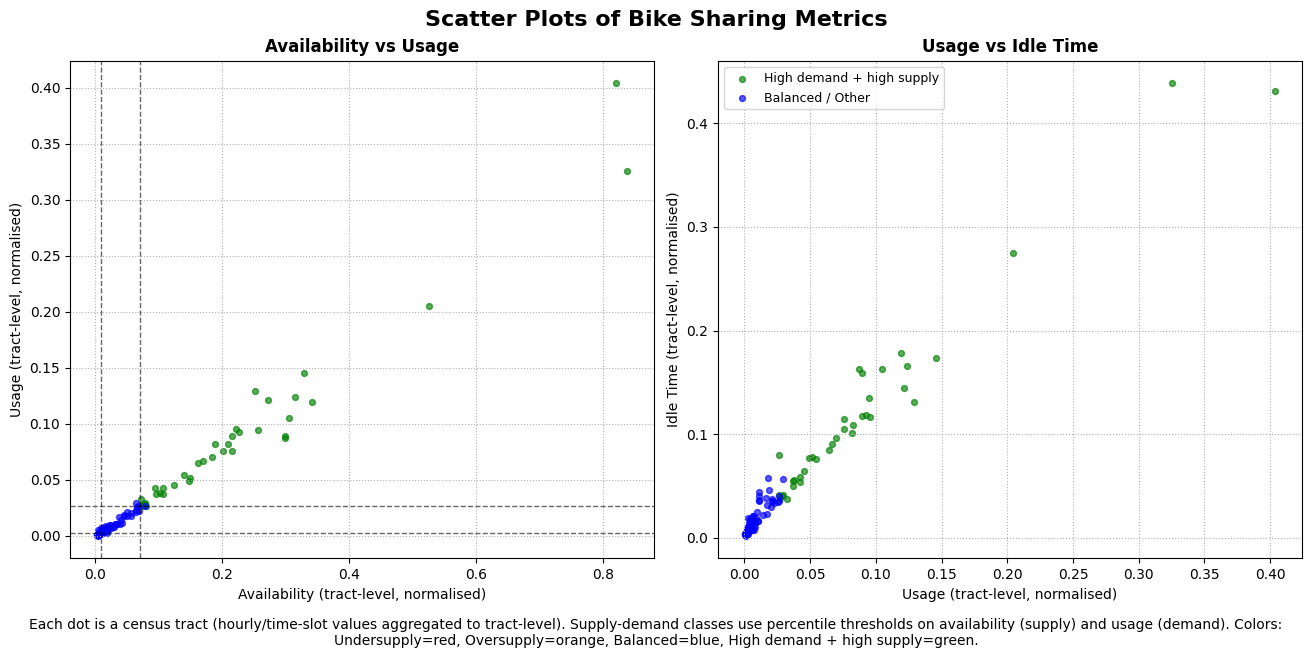

In [9]:
# ============================================================
# Cell 7 — Supply / Demand Scatter Plot
# ============================================================
master, class_df, fig = scatter_visual.plot_scatter(
    availability_csv          = f"{SEA_OUT}/availability_norm_hourly_tract_{SEA_TAG}.csv",
    usage_csv                 = f"{SEA_OUT}/usage_norm_hourly_tract_{SEA_TAG}.csv",
    idle_csv                  = f"{SEA_OUT}/idle_norm_hourly_tract_{SEA_TAG}.csv",
    output_dir                = f"{SEA_OUT}/SCATTER",
    threshold_method          = "percent",
    use_symmetric_percentiles = True,
    availability_low_pct      = 30,
    usage_high_pct            = 70,
    show_threshold_debug      = True,
)

display(class_df)

## Cell 8 — Fairness Trend

Shows how Gini coefficient and Alpha fairness evolve hour by hour over
time. Three plots are produced per metric:
1. Mean ± SD over time
2. Gini Coefficient over time
3. Alpha Fairness over time

**This cell has two modes — set `TREND_MODE` to choose:**

- `"single"` — uses the single day of CSVs already produced by Cell 3.
  Plots will run and save but the trend line will be flat. Useful for
  verifying the pipeline works end to end.

- `"weekly"` — uses 7 days of daily CSVs collected into three folders.
  This is the correct mode for the paper. To collect a week of data,
  run Cell 3 once per day and copy each day's availability, usage, and
  idle time CSVs into the folders below.

Expected folder structure for weekly mode:
```
SEATTLE_BIRD_ASSETS/WEEKLY/
  availability/
    availability_norm_hourly_tract_seattle_bird_day1.csv
    availability_norm_hourly_tract_seattle_bird_day2.csv
    ...  (one file per day, 7 total)
  usage/
    usage_norm_hourly_tract_seattle_bird_day1.csv
    ...
  idle_time/
    idle_norm_hourly_tract_seattle_bird_day1.csv
    ...
```

Single-day mode. Trend will be flat — this is expected.

[SEATTLE_BIRD_DOCKLESS] Running plot_all trend visualizations...
  [Availability] Fairness CSV saved: SEATTLE_BIRD_ASSETS\SEATTLE_BIRD_OUTPUT\TREND\SEATTLE_BIRD_DOCKLESS__availability_trend.csv


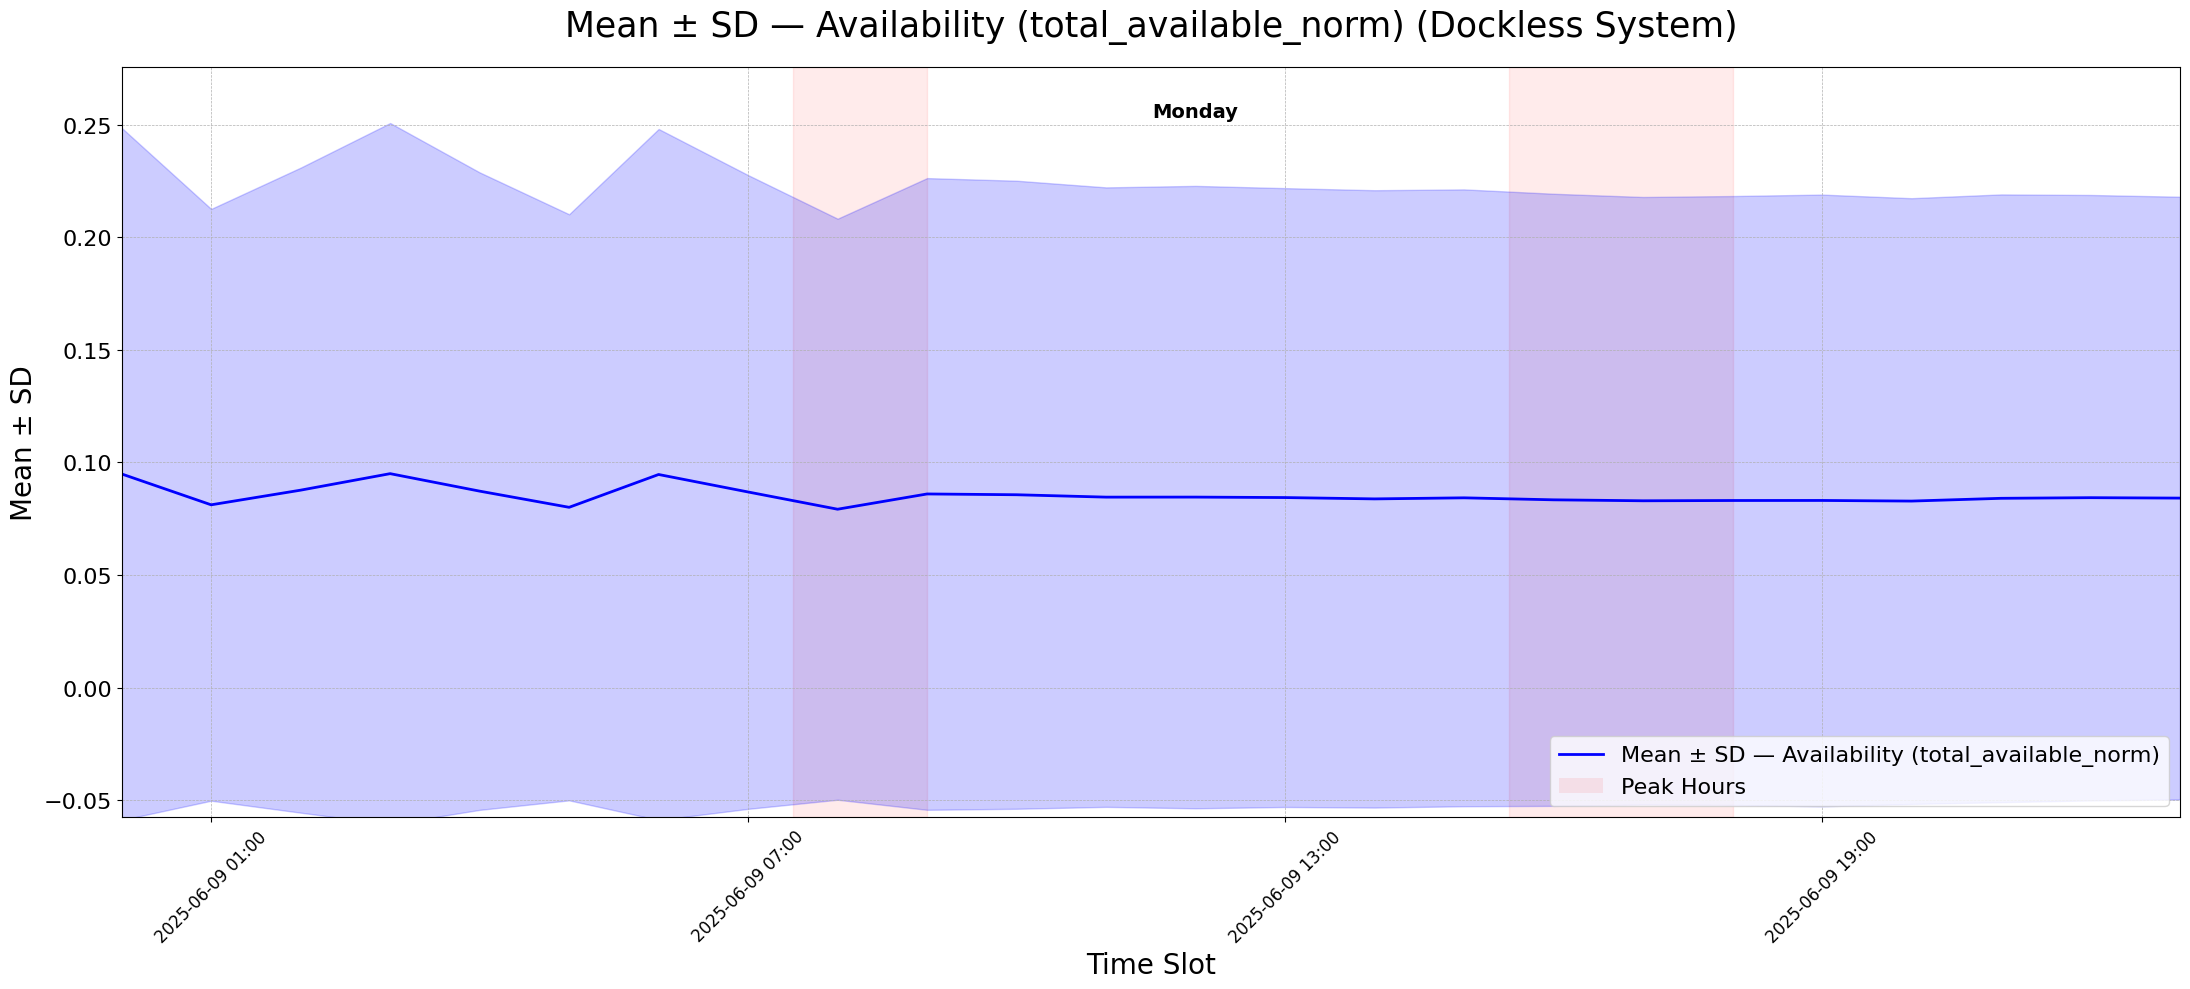

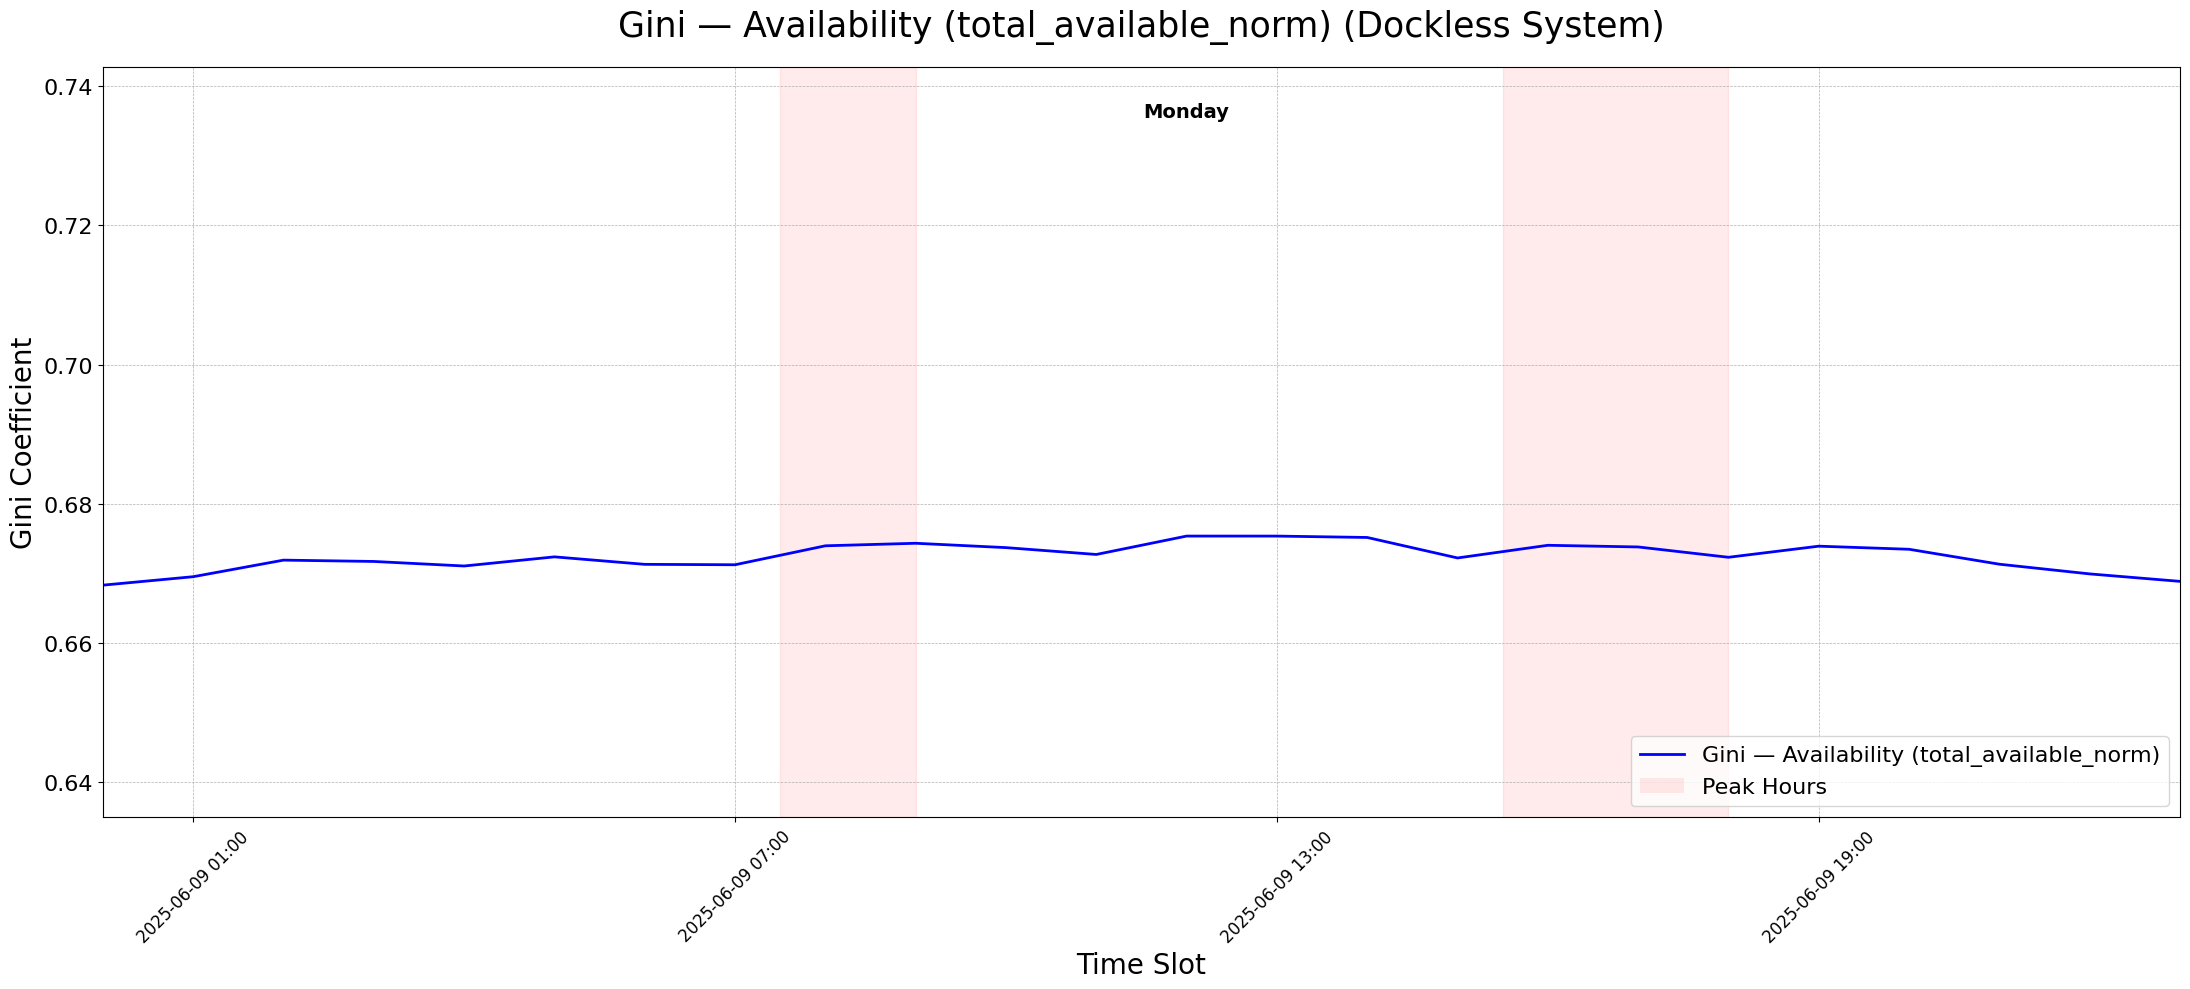

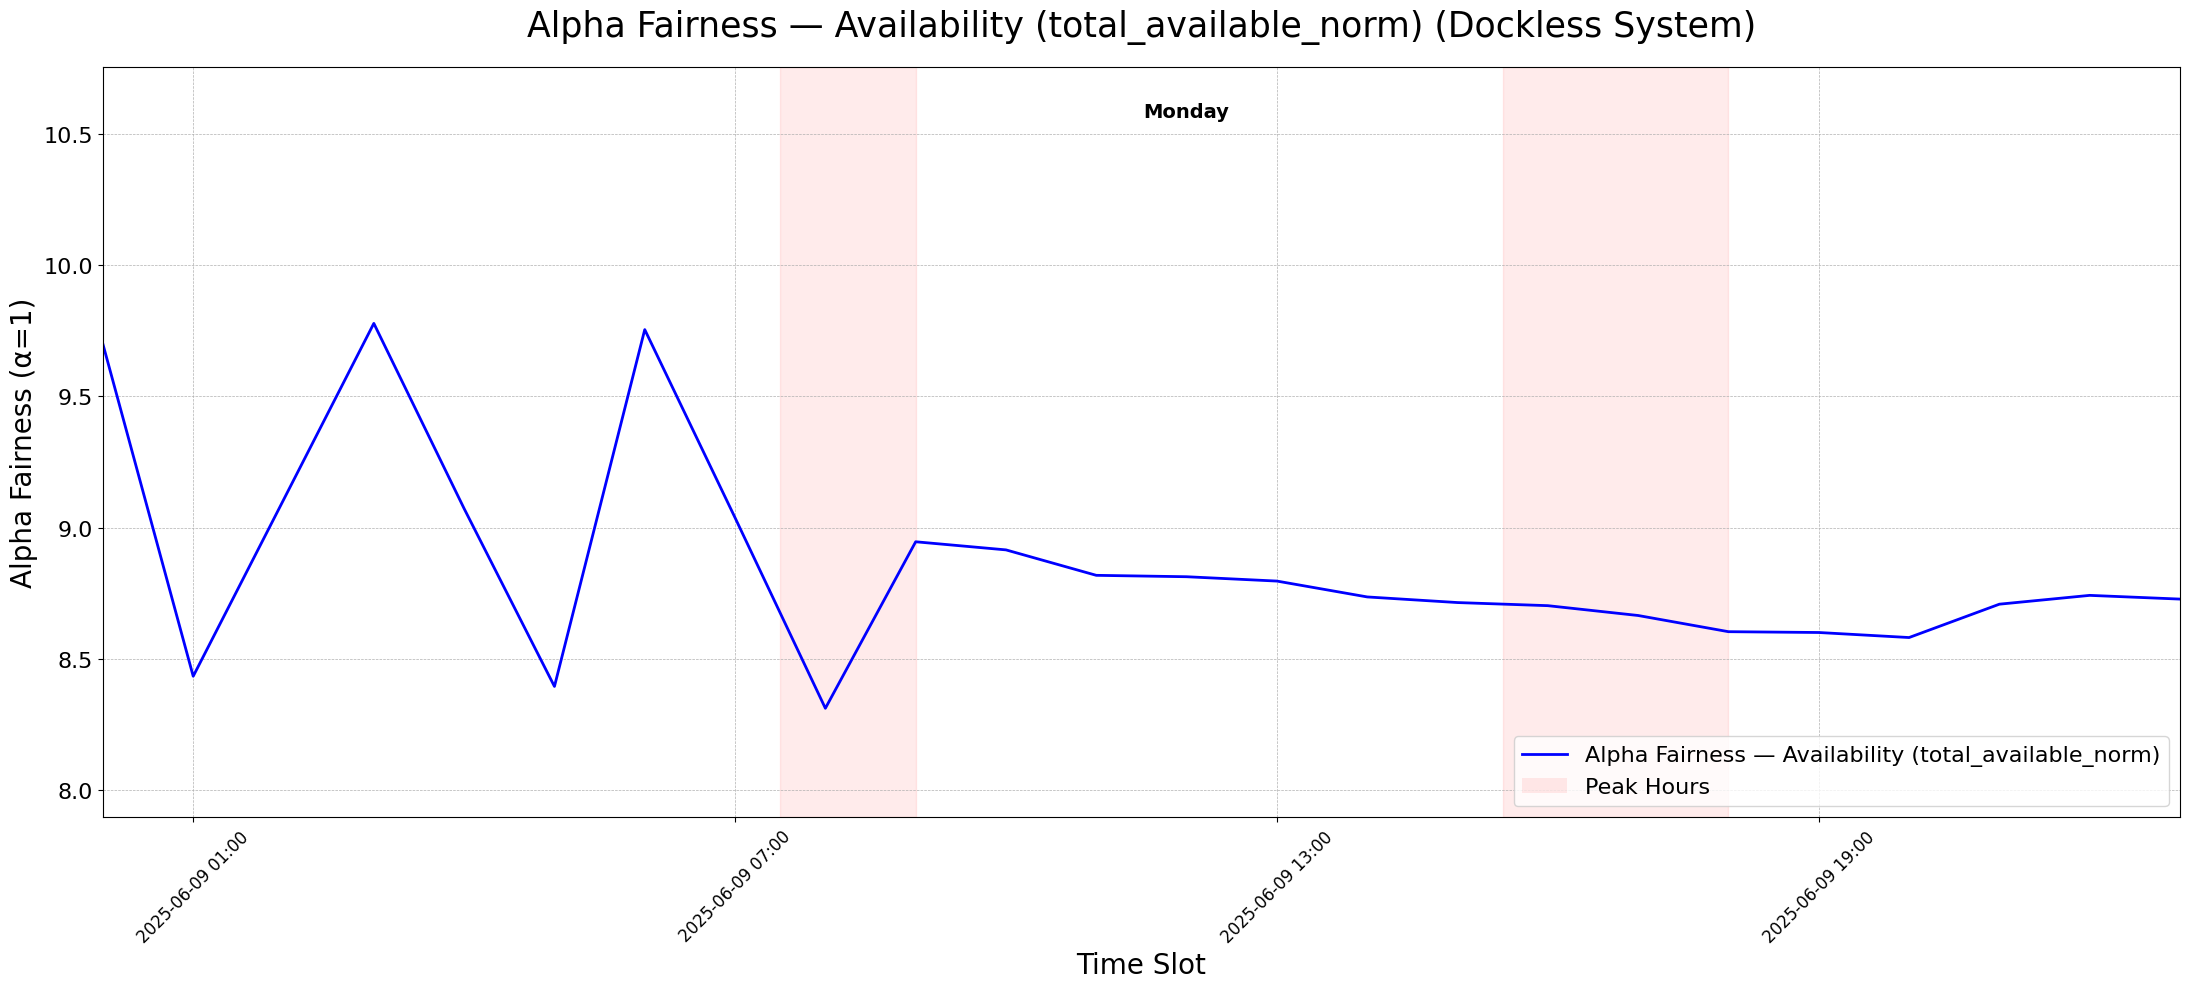

  [Availability] Plots saved for: Availability (total_available_norm)
  [Usage] Fairness CSV saved: SEATTLE_BIRD_ASSETS\SEATTLE_BIRD_OUTPUT\TREND\SEATTLE_BIRD_DOCKLESS__usage_trend.csv


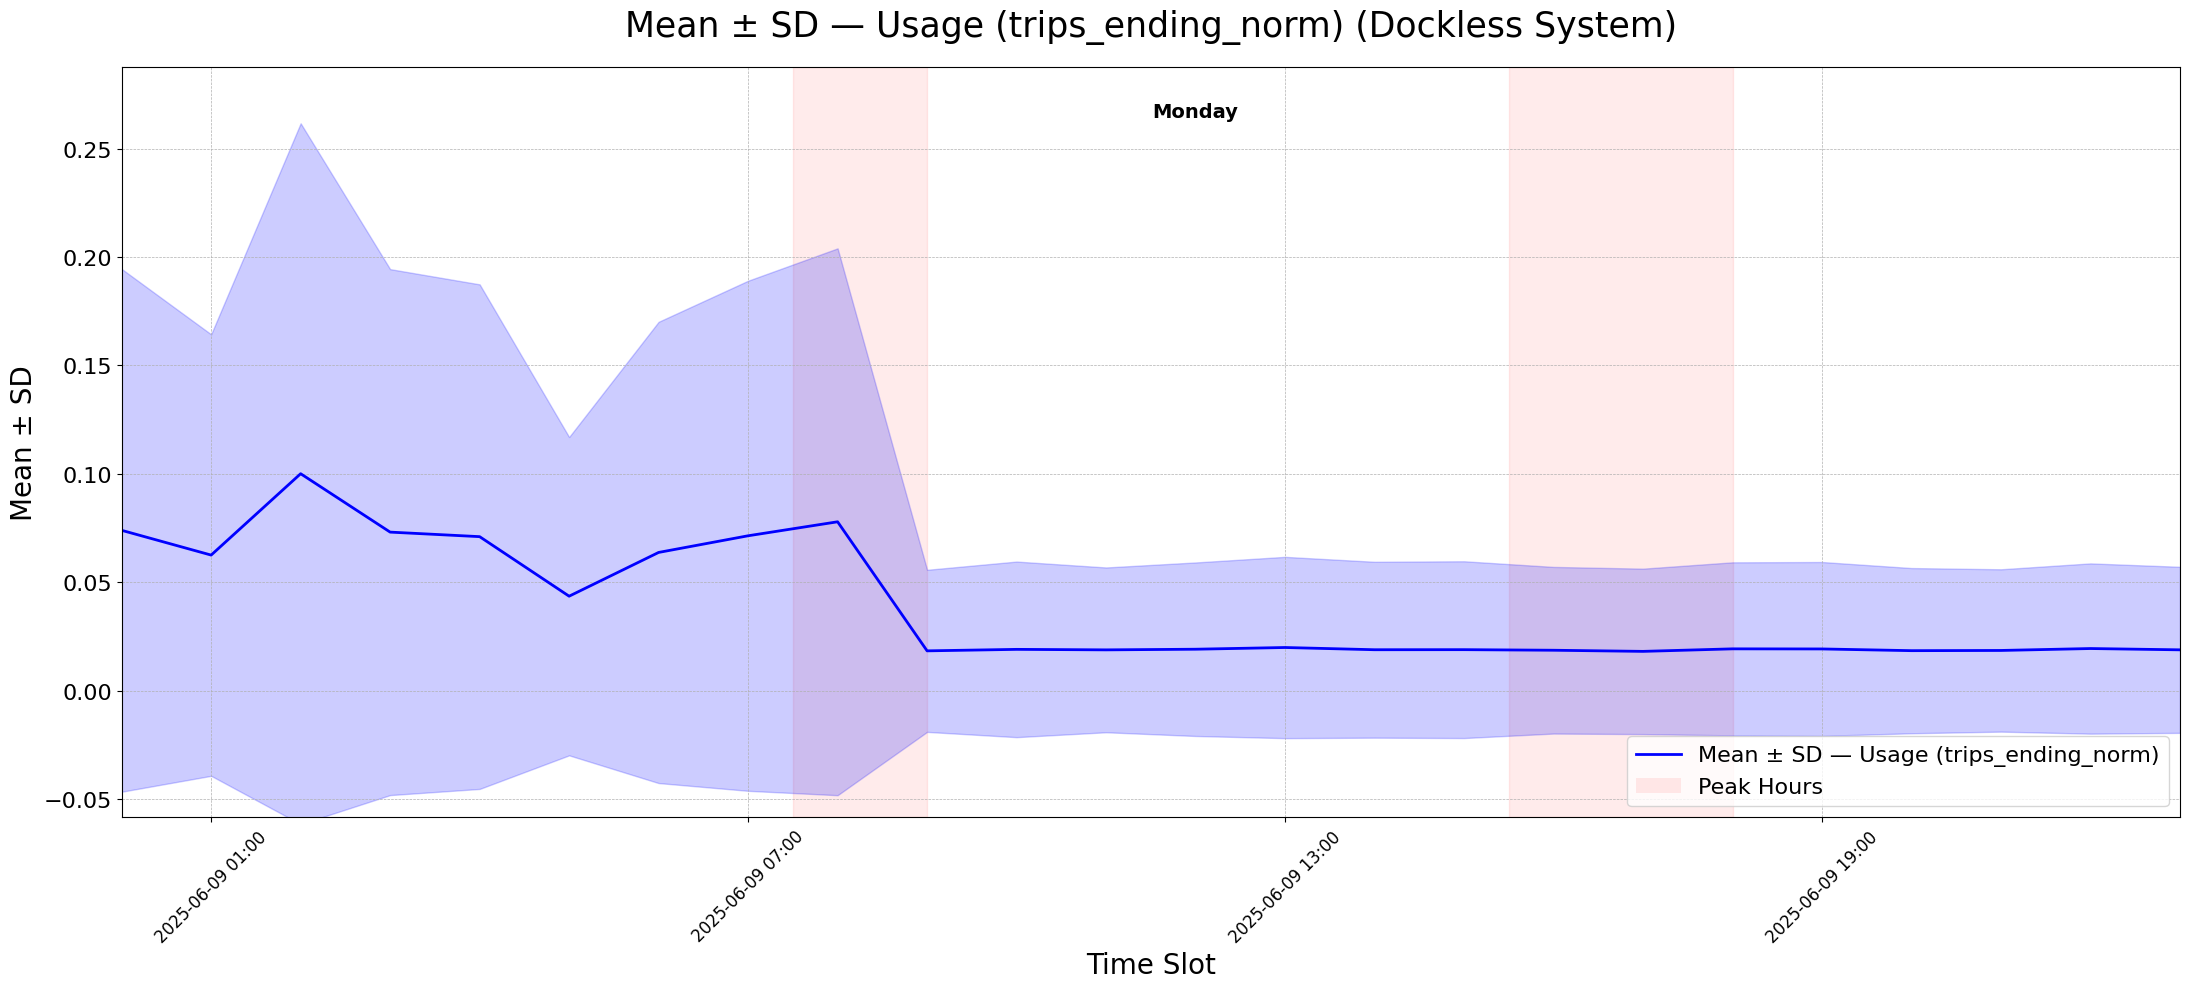

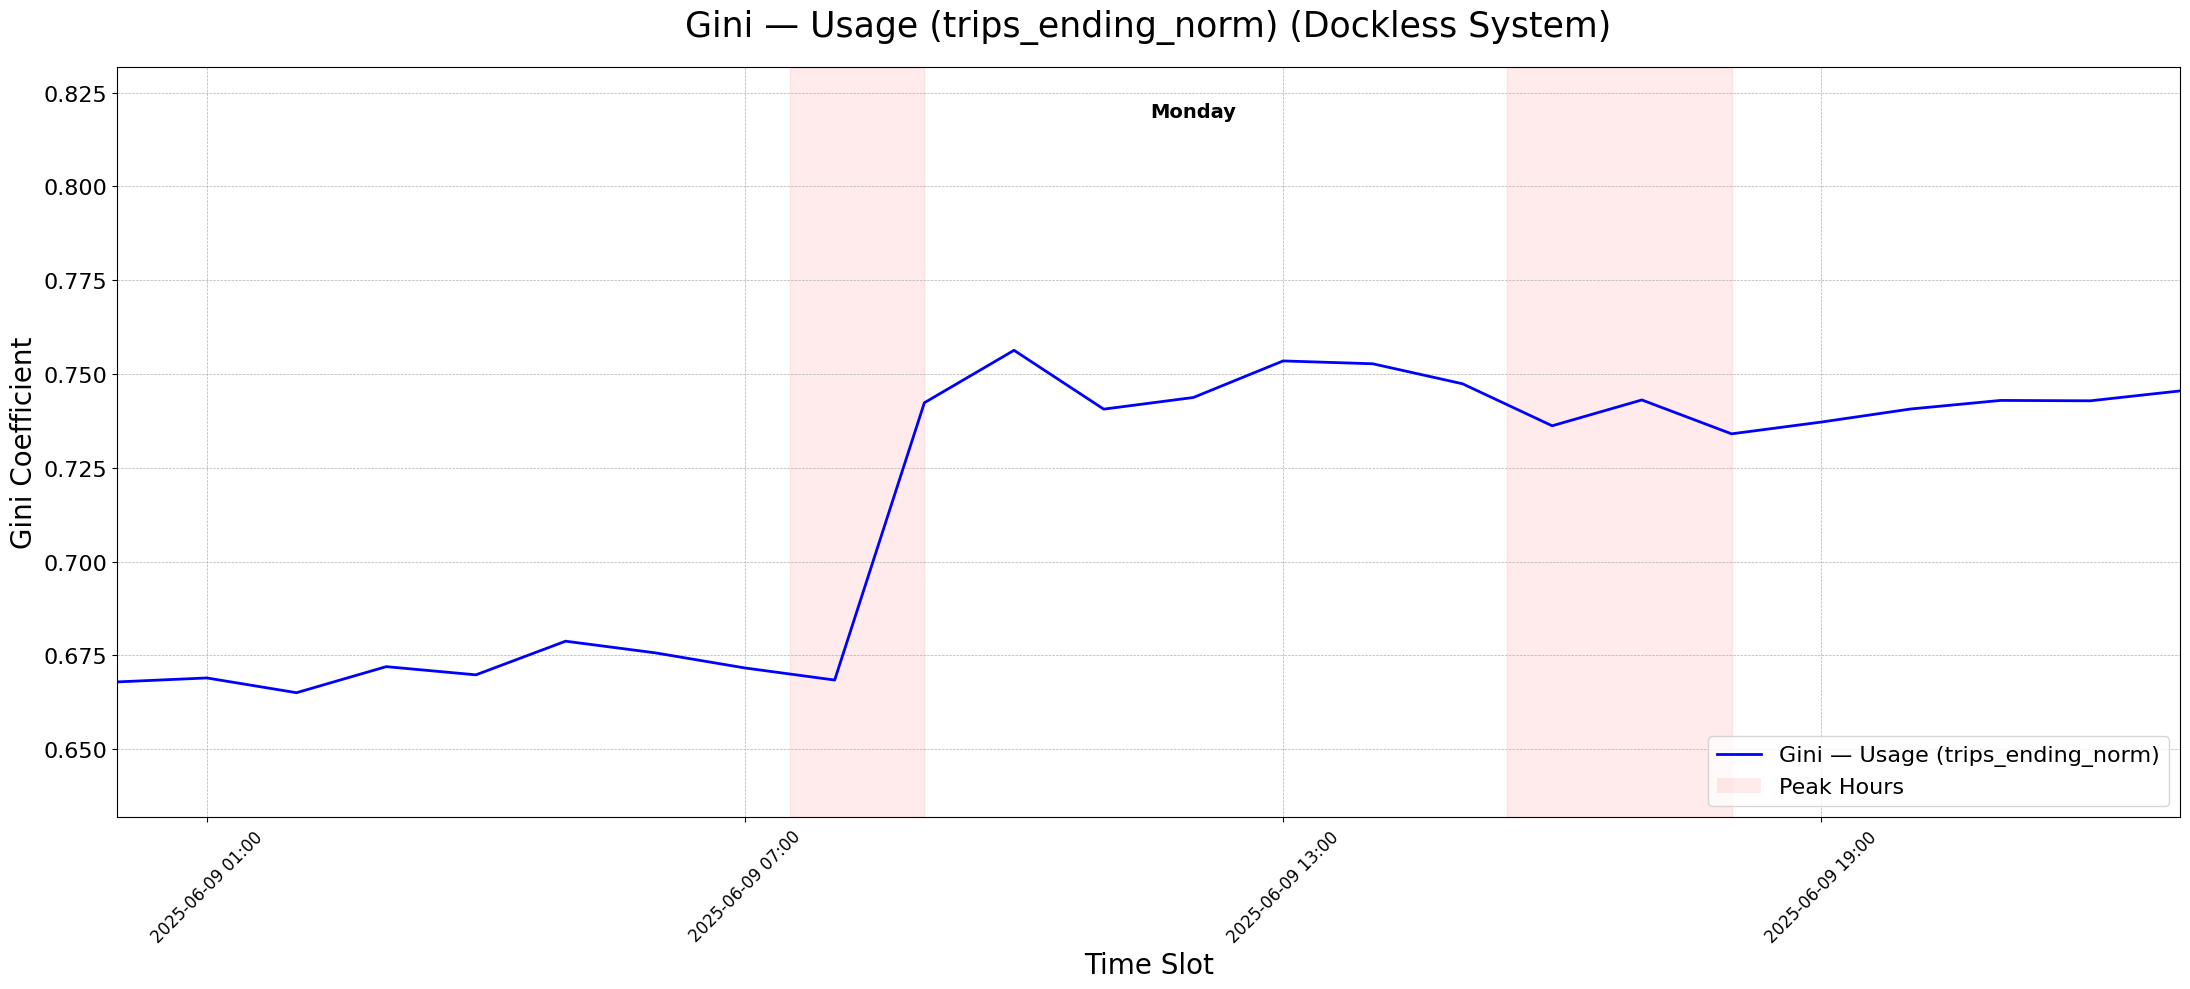

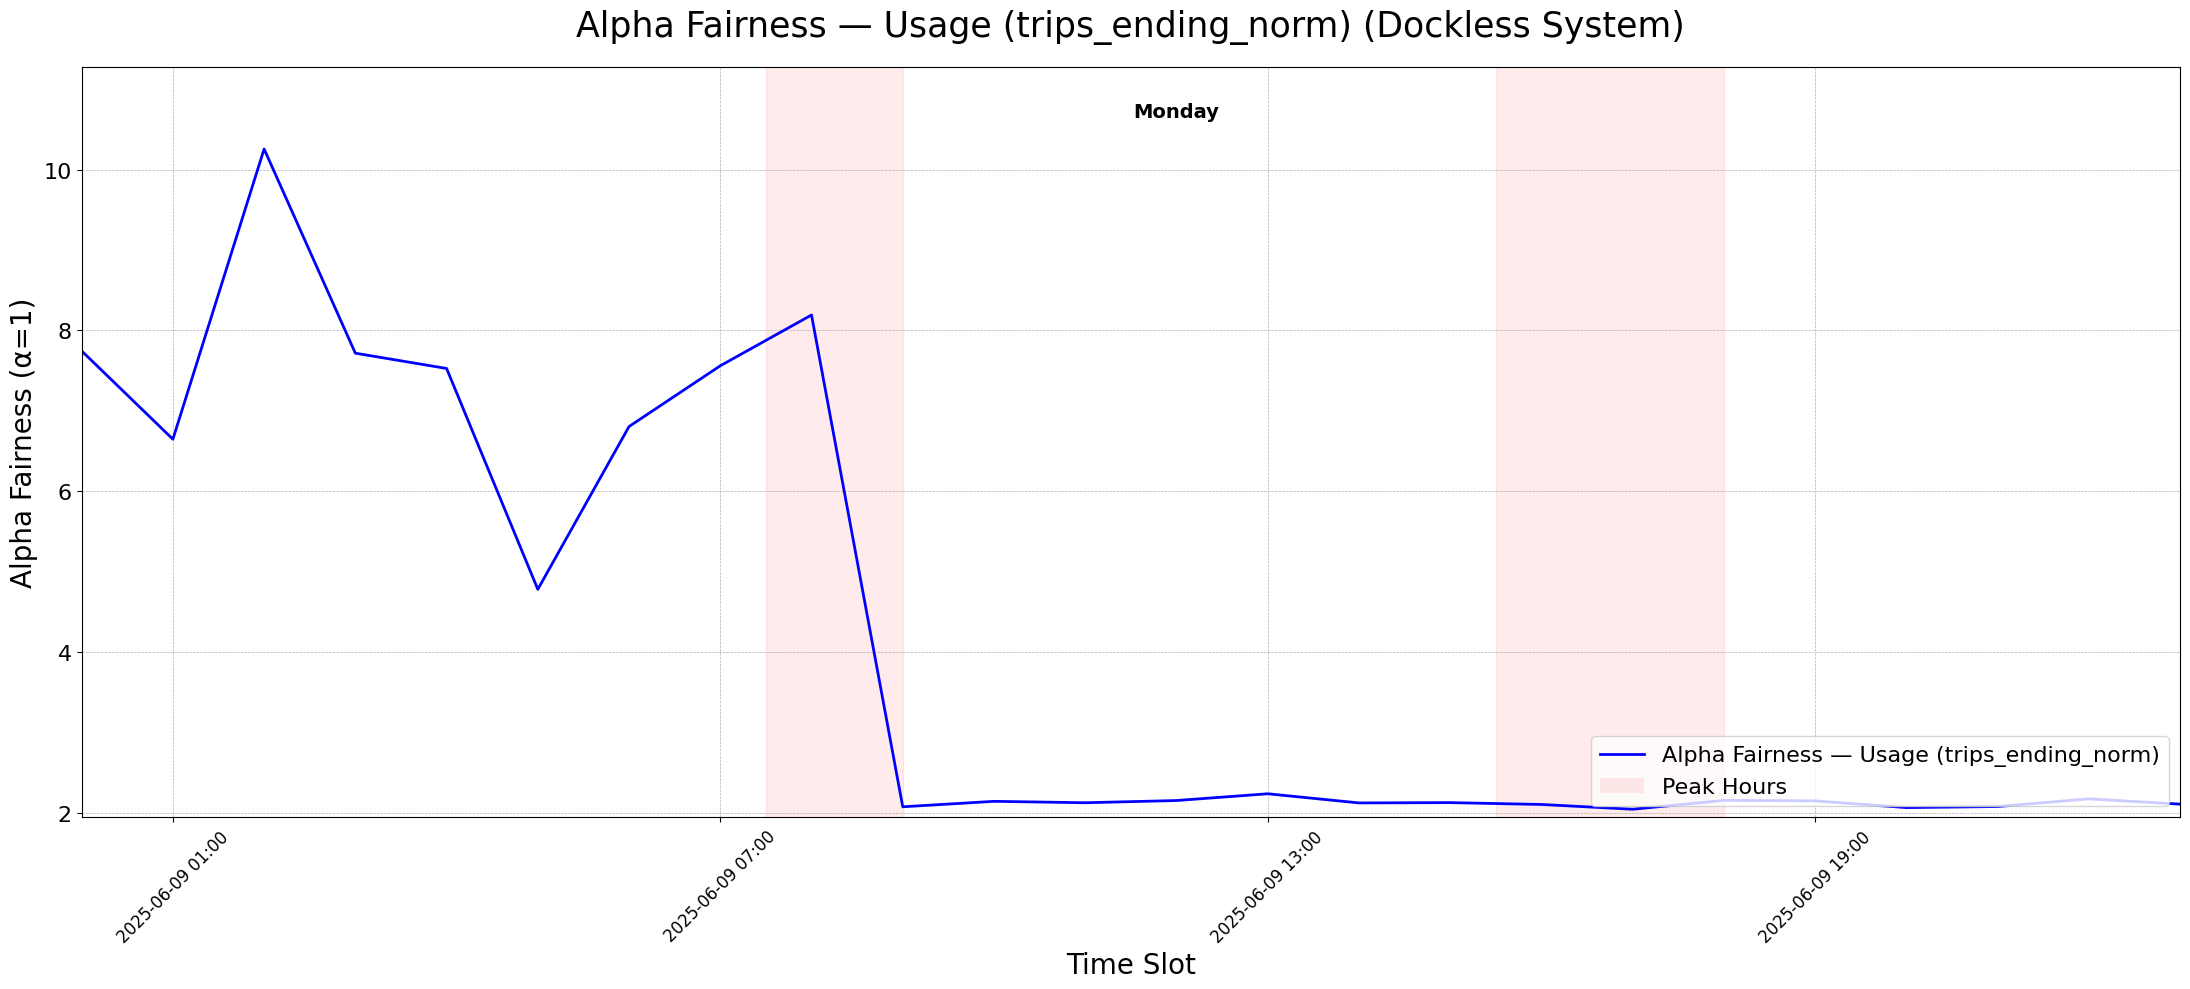

  [Usage] Plots saved for: Usage (trips_ending_norm)


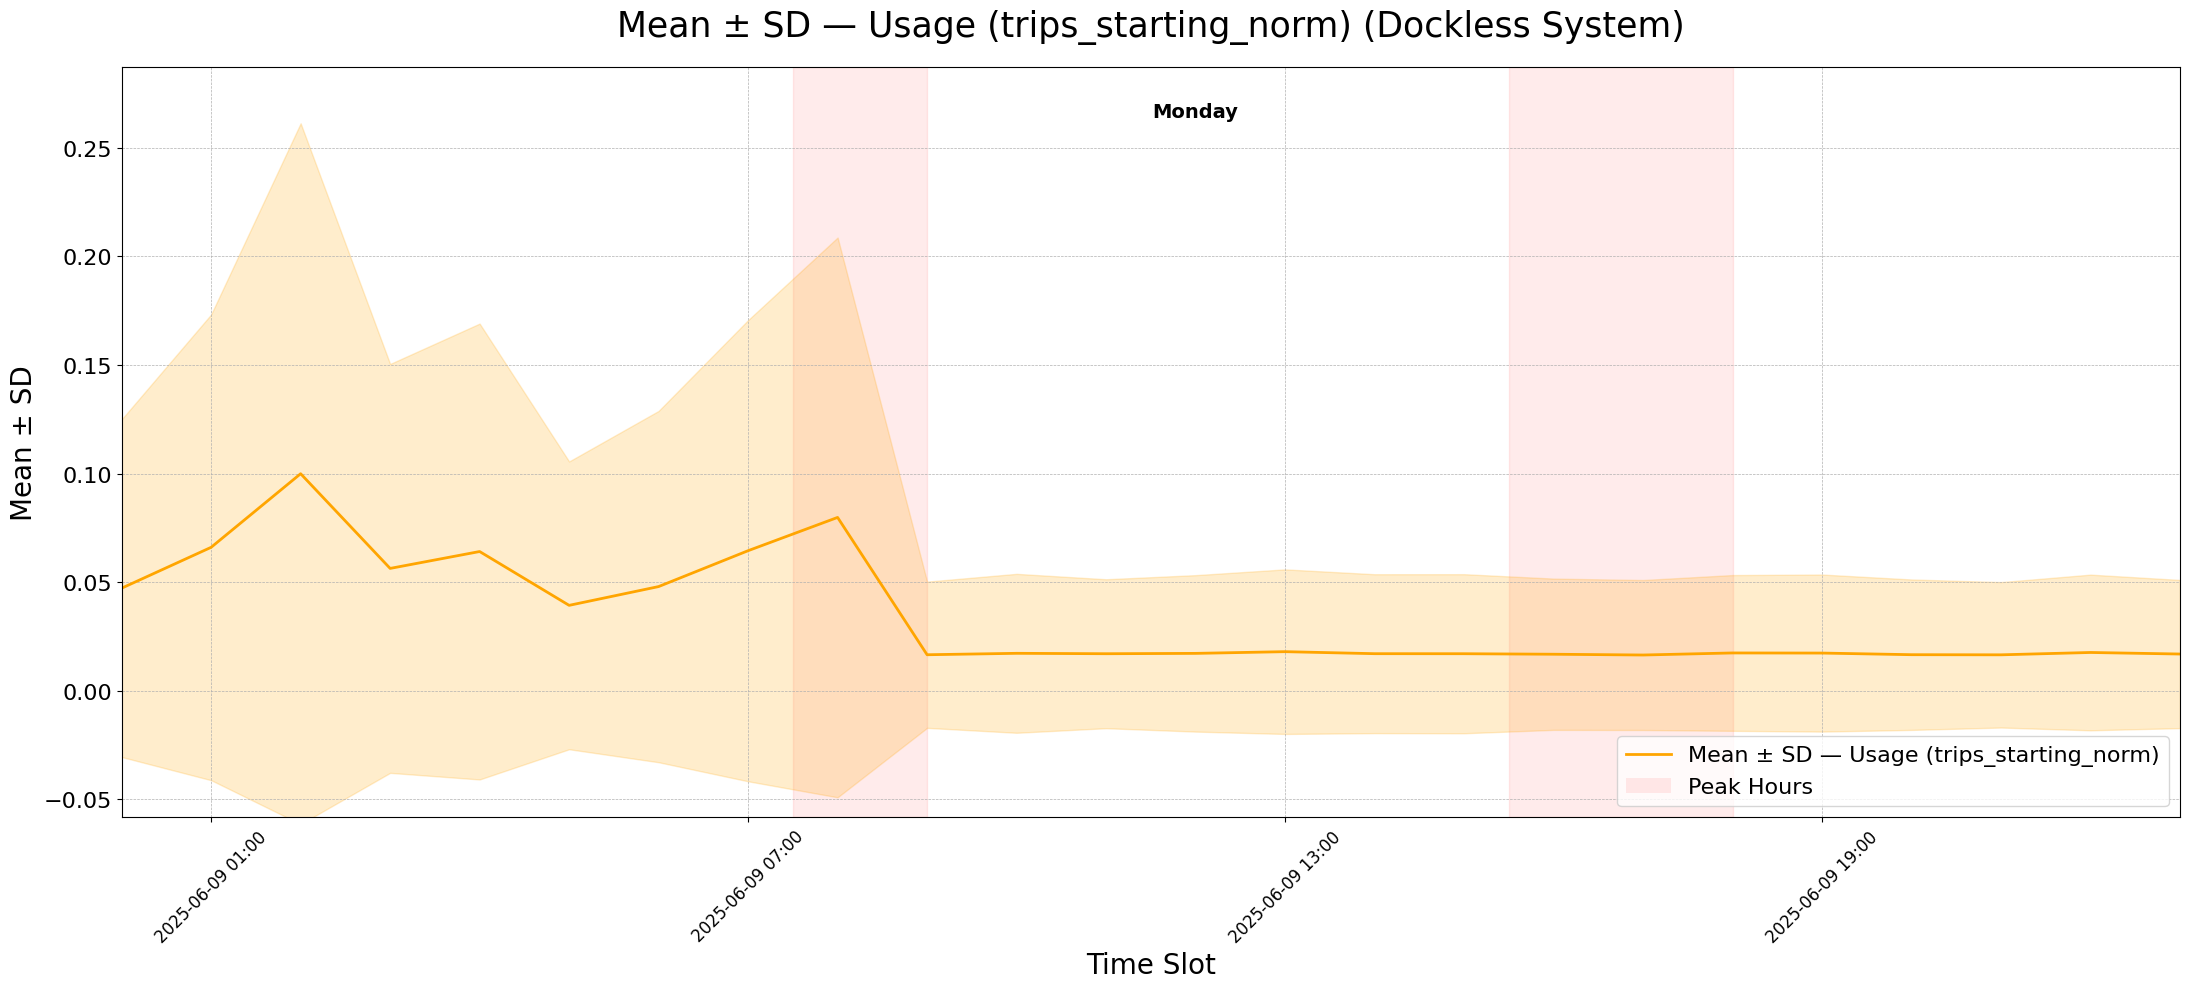

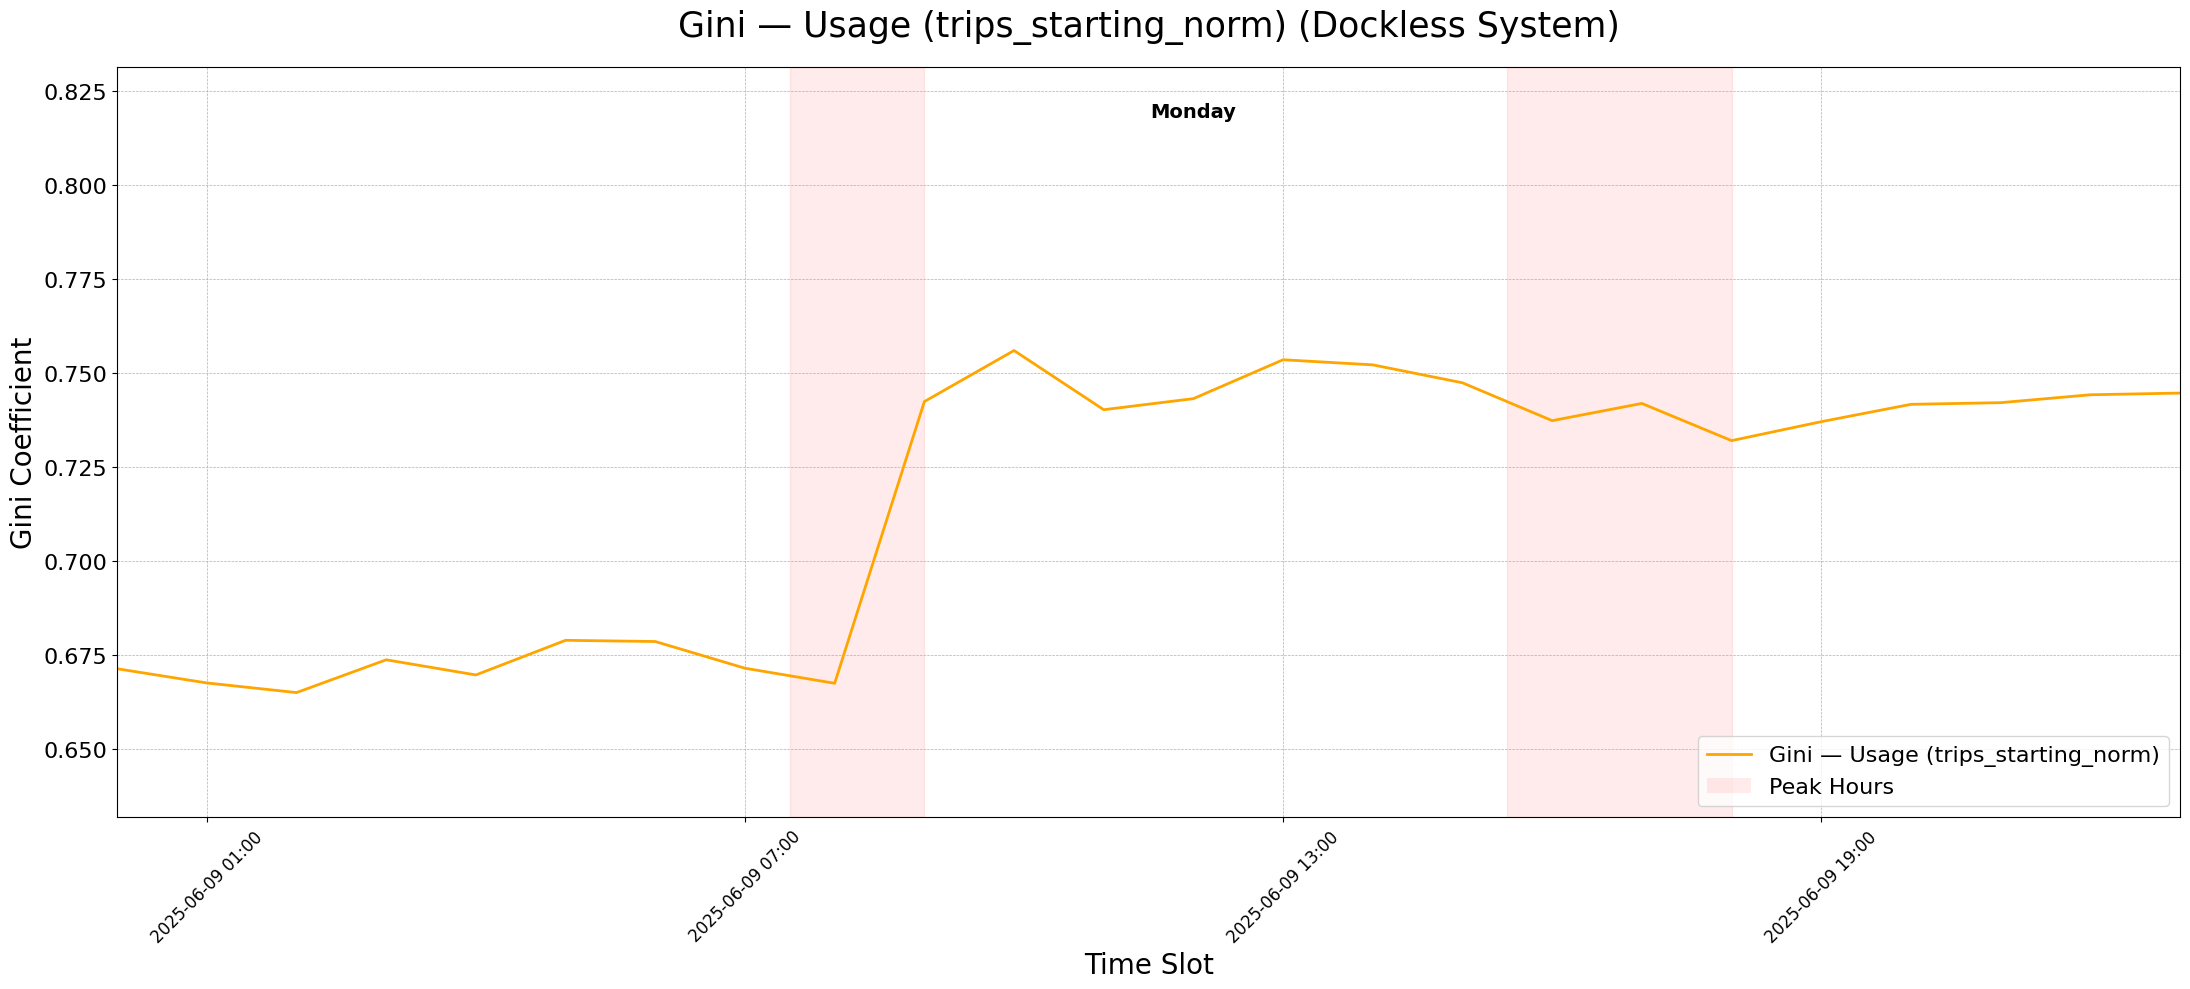

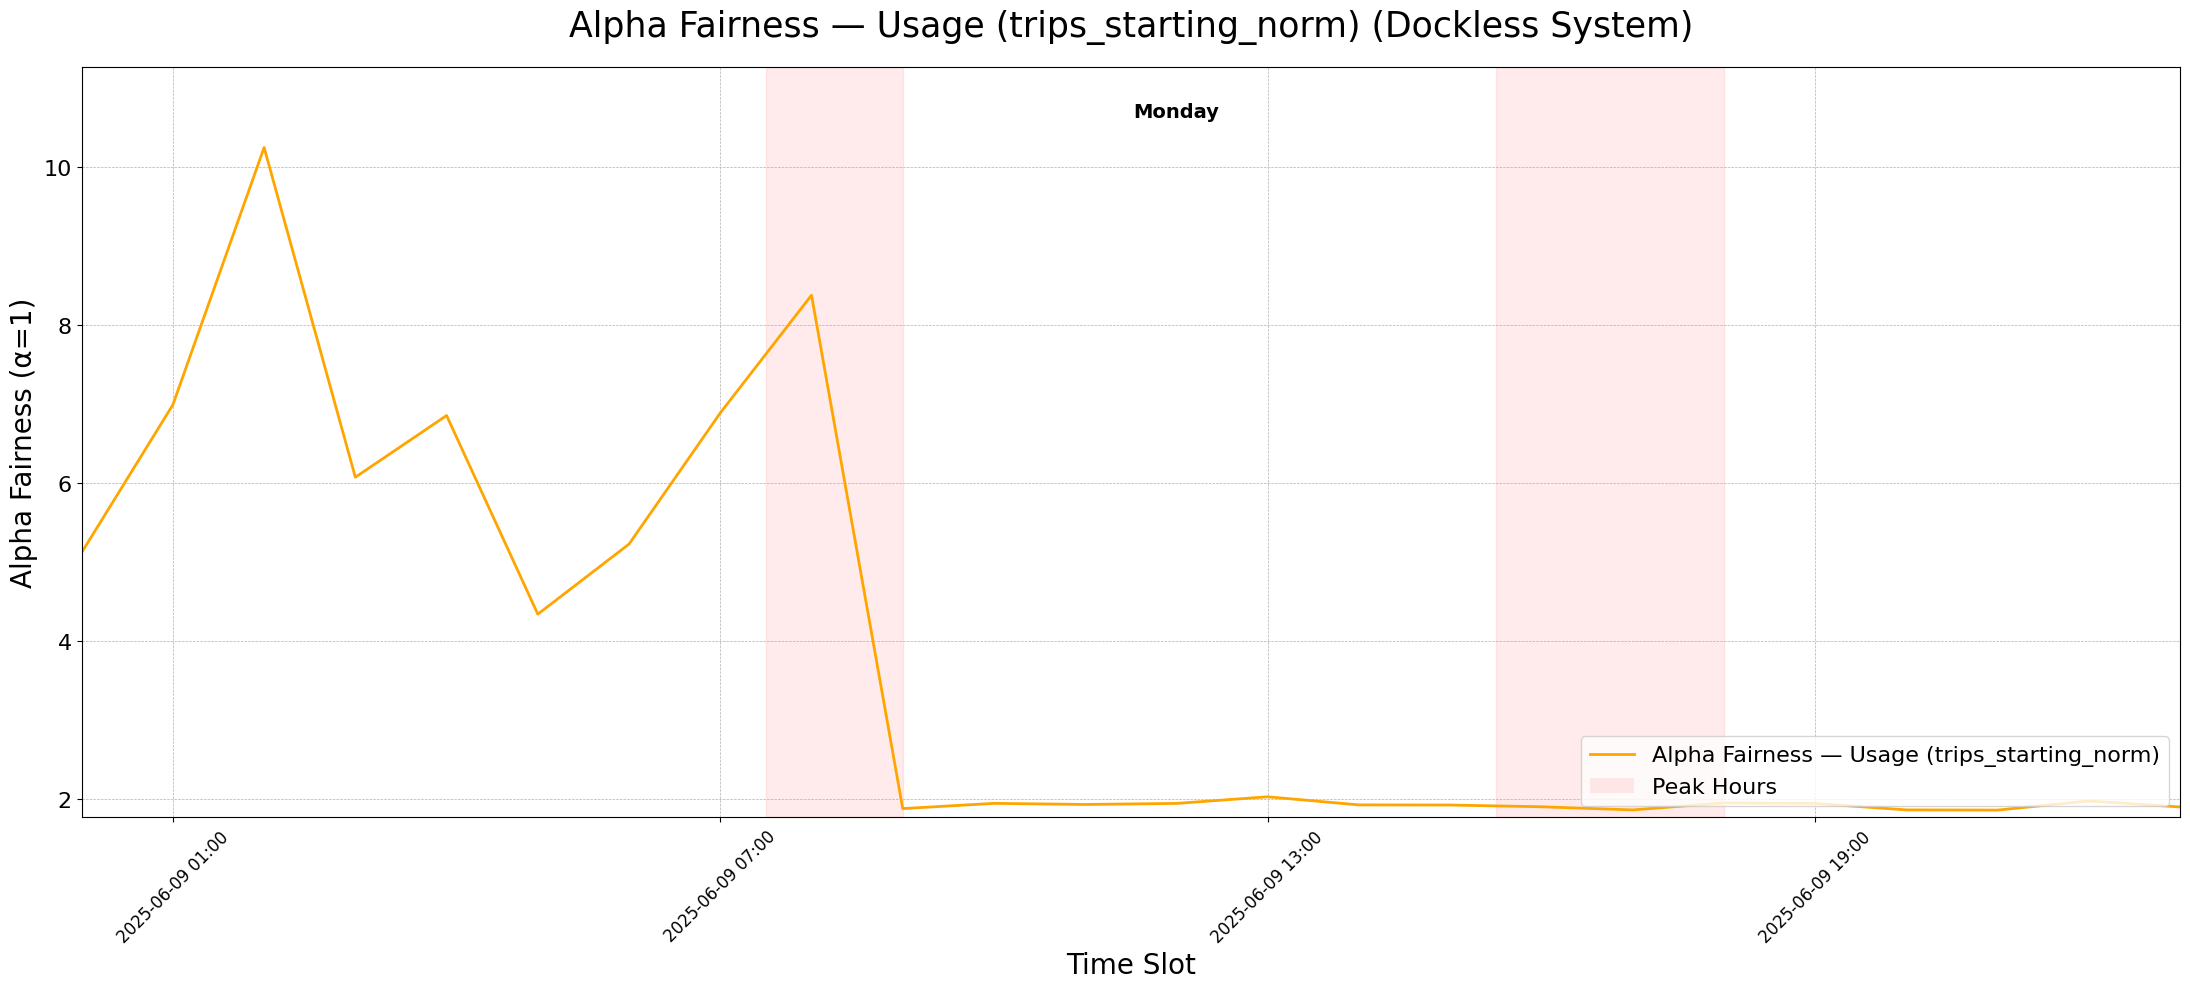

  [Usage] Plots saved for: Usage (trips_starting_norm)
  [Idle Time] Fairness CSV saved: SEATTLE_BIRD_ASSETS\SEATTLE_BIRD_OUTPUT\TREND\SEATTLE_BIRD_DOCKLESS__idle_time_trend.csv


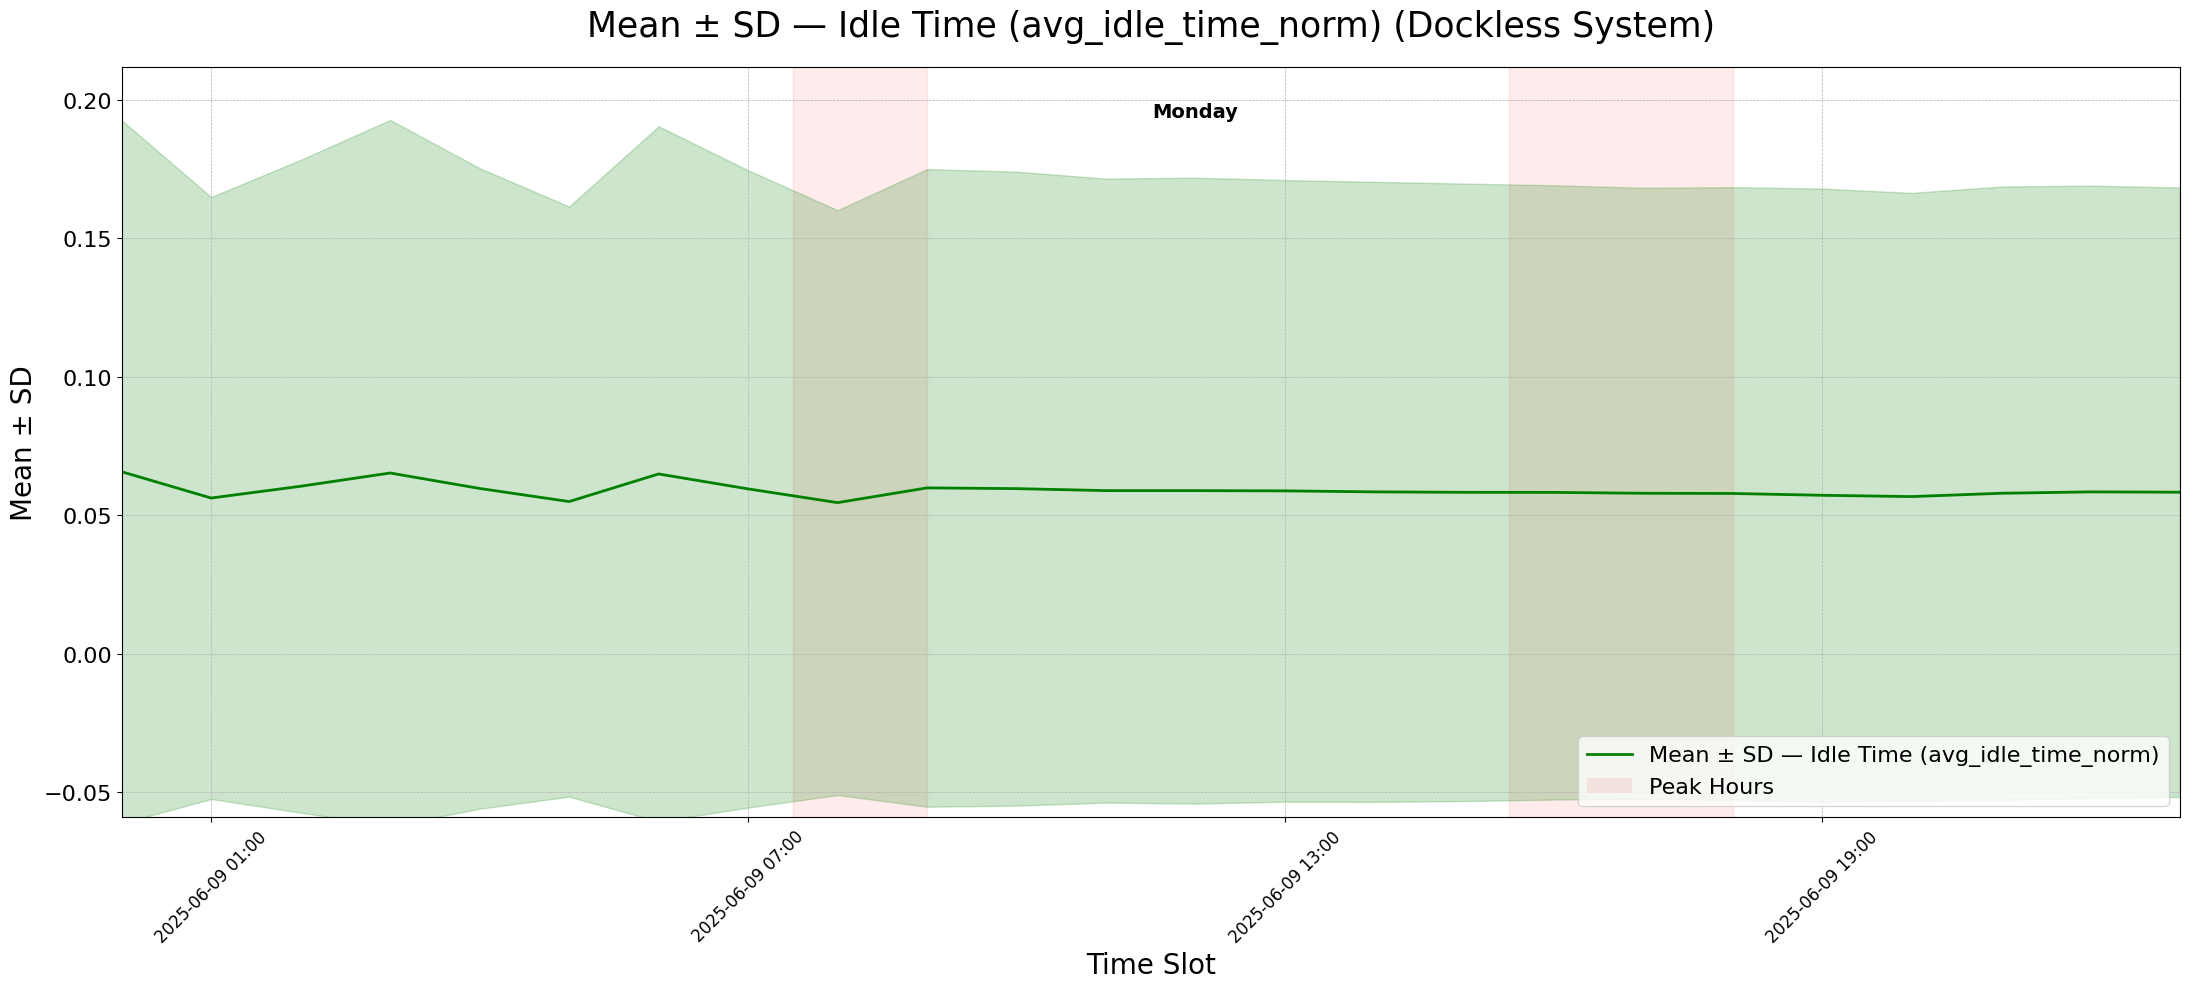

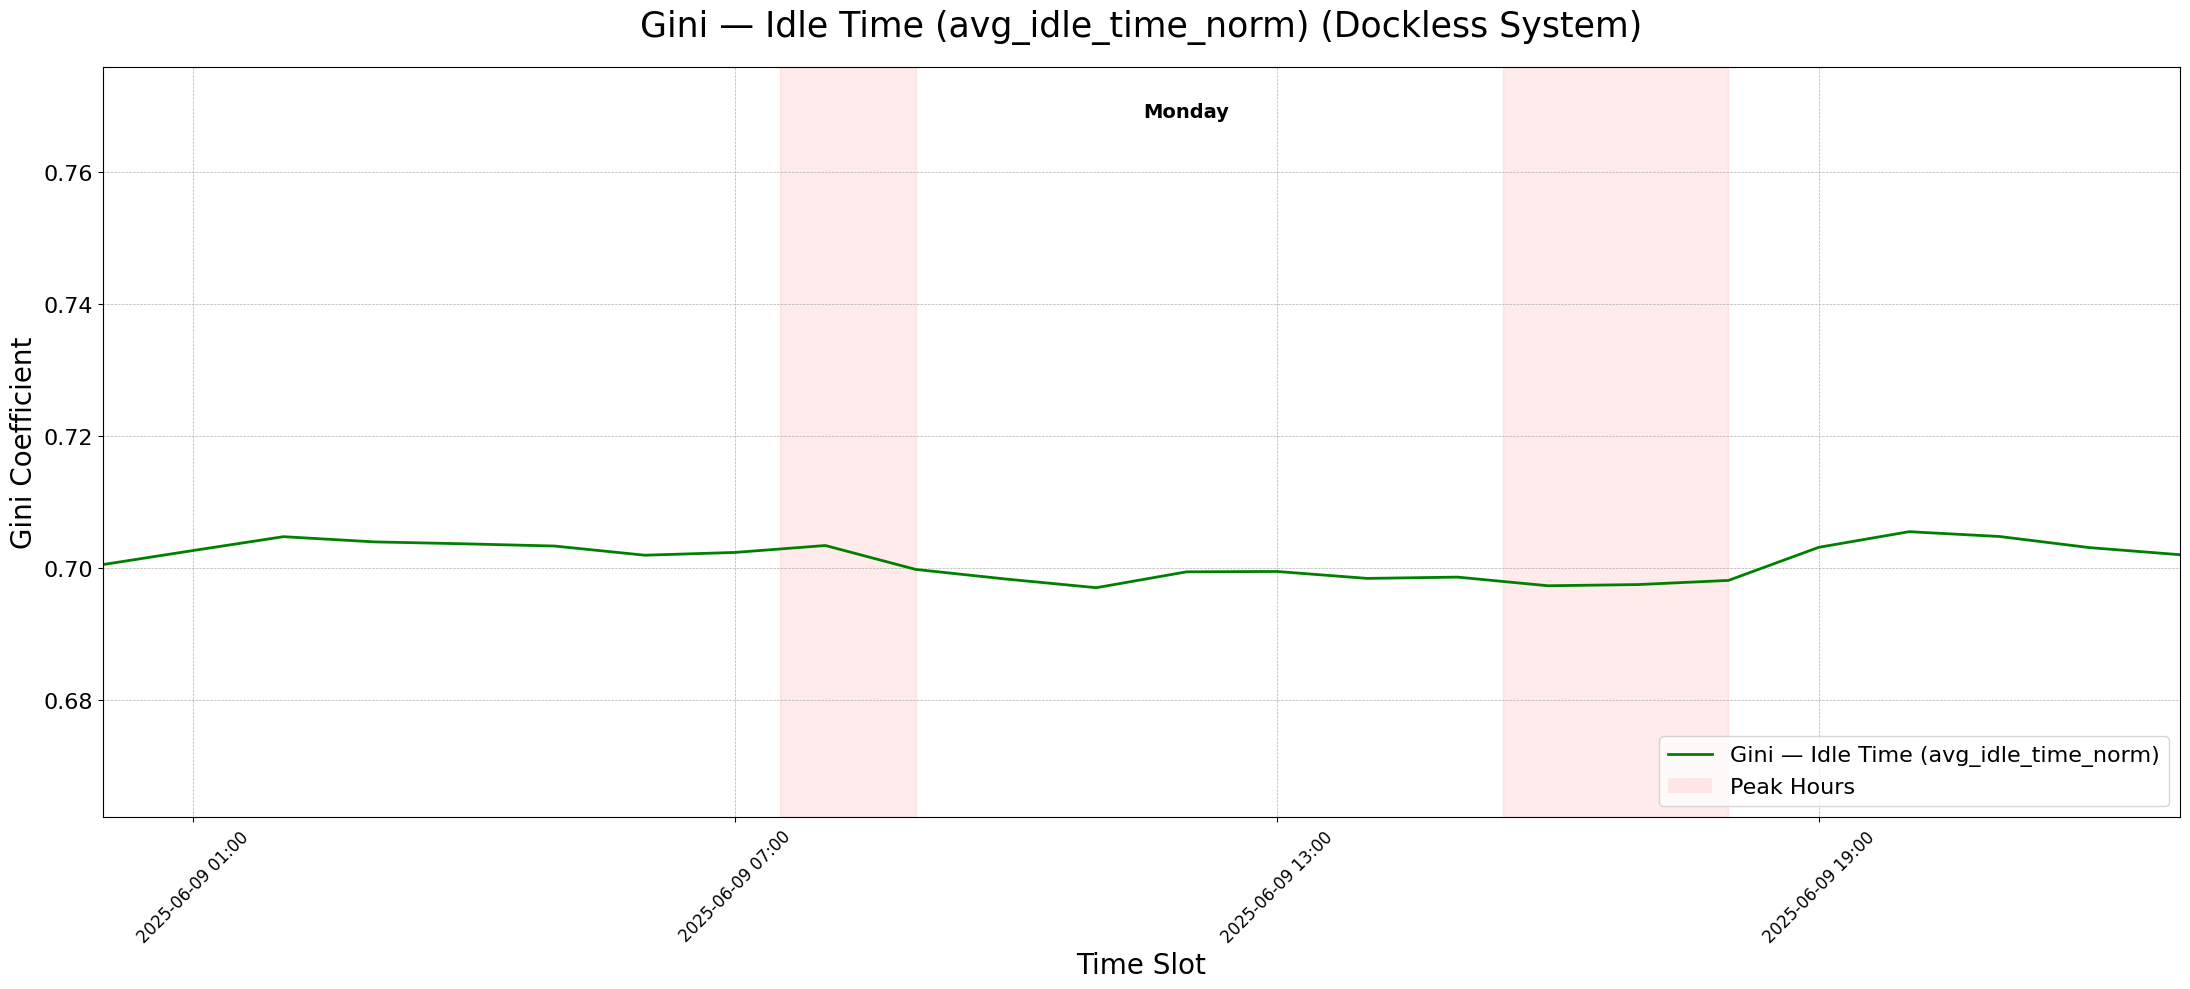

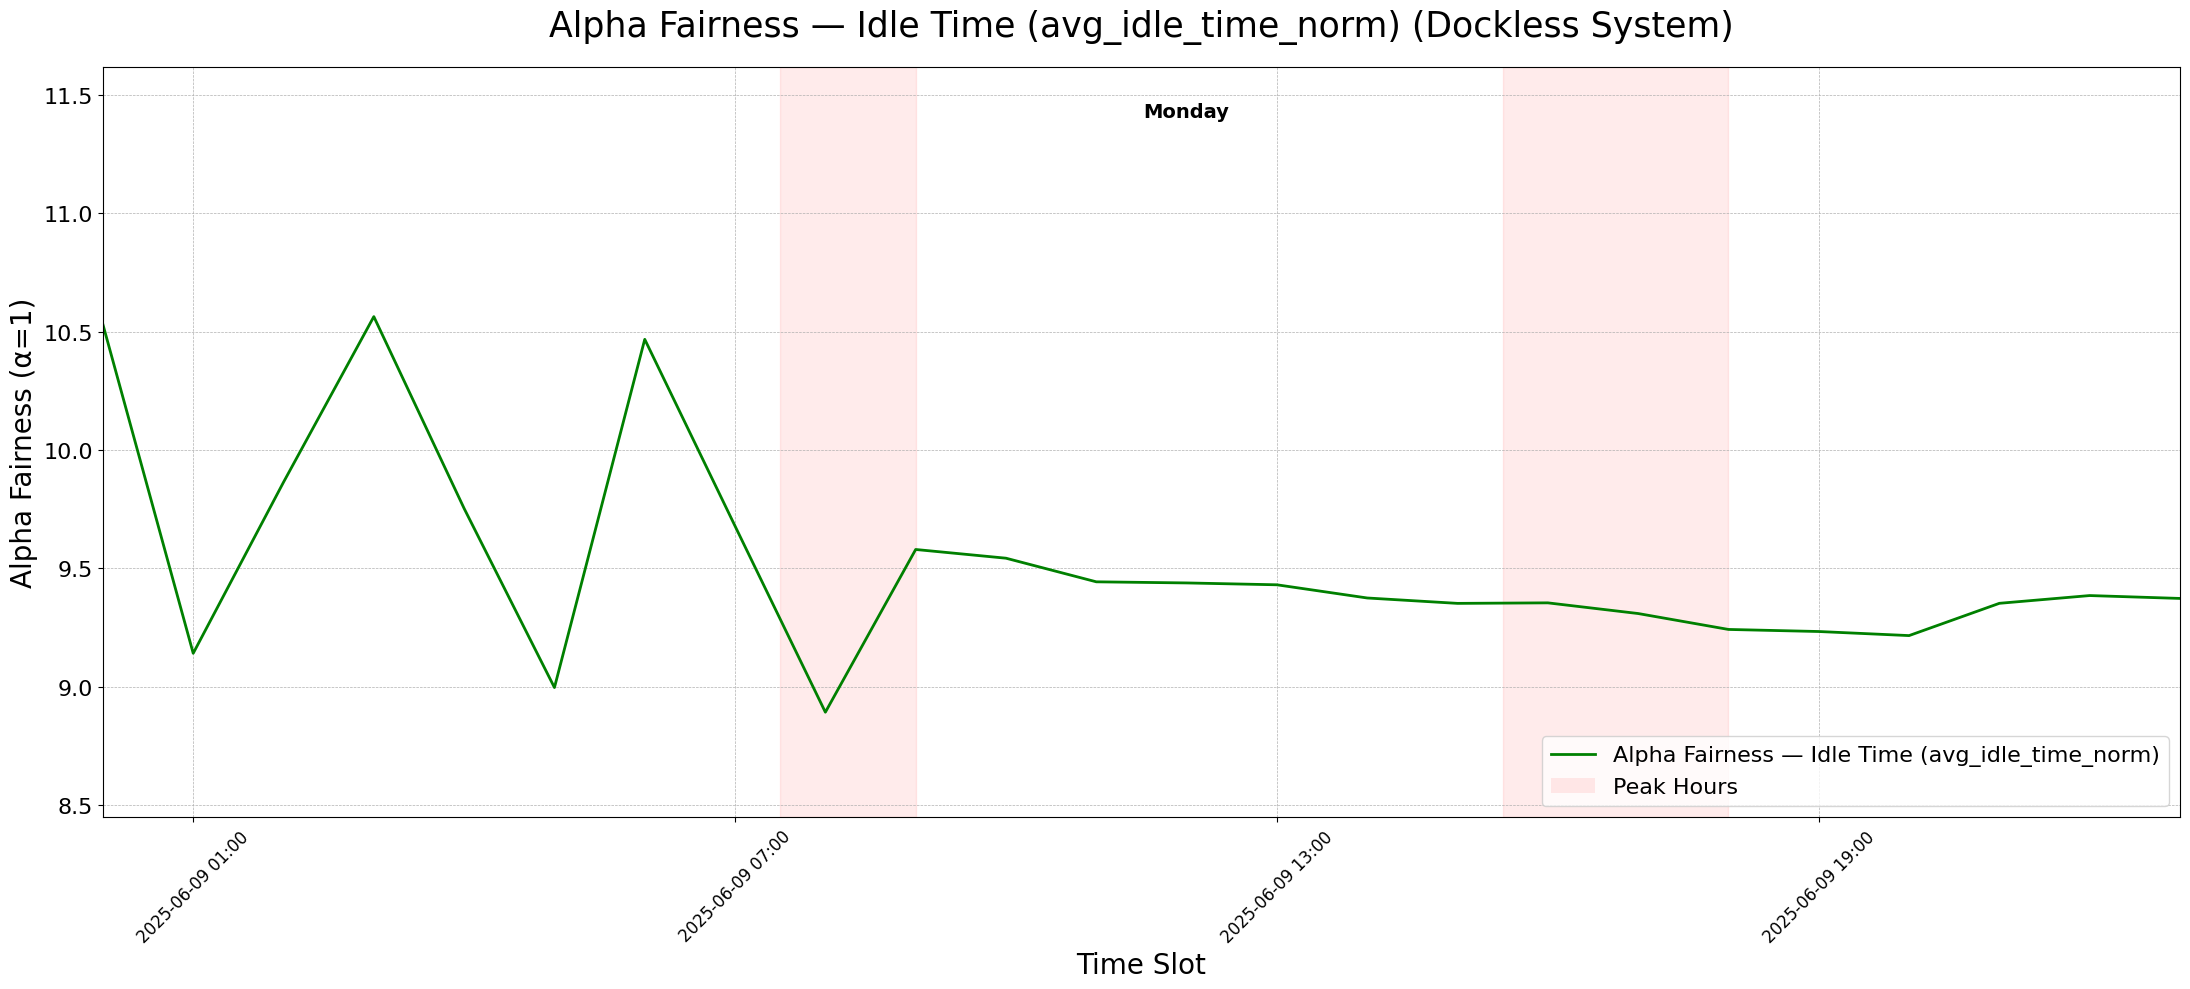

  [Idle Time] Plots saved for: Idle Time (avg_idle_time_norm)
[SEATTLE_BIRD_DOCKLESS] All trend plots complete. Outputs in: SEATTLE_BIRD_ASSETS\SEATTLE_BIRD_OUTPUT\TREND


{'availability': {'plot_paths': {'Availability (total_available_norm)::MeanSD': 'SEATTLE_BIRD_ASSETS\\SEATTLE_BIRD_OUTPUT\\TREND\\MeanSD_Overall_Availability_total_available_norm.png',
   'Availability (total_available_norm)::Gini': 'SEATTLE_BIRD_ASSETS\\SEATTLE_BIRD_OUTPUT\\TREND\\Gini_Overall_Availability_total_available_norm.png',
   'Availability (total_available_norm)::Alpha': 'SEATTLE_BIRD_ASSETS\\SEATTLE_BIRD_OUTPUT\\TREND\\AlphaFairness_Overall_Availability_total_available_norm.png'},
  'results_df':              Time Slot     Boro                               Metric  \
  0  2025-06-09 00:00:00  Overall  Availability (total_available_norm)   
  1  2025-06-09 01:00:00  Overall  Availability (total_available_norm)   
  2  2025-06-09 02:00:00  Overall  Availability (total_available_norm)   
  3  2025-06-09 03:00:00  Overall  Availability (total_available_norm)   
  4  2025-06-09 04:00:00  Overall  Availability (total_available_norm)   
  5  2025-06-09 05:00:00  Overall  Availabil

In [10]:
# ============================================================
# Cell 8 — Fairness Trend
# ============================================================

# "single" → use today's CSVs (flat trend, pipeline check only)
# "weekly" → use a folder of 7 daily CSVs (correct for the paper)
TREND_MODE = "single"

if TREND_MODE == "single":
    availability_input = f"{SEA_OUT}/availability_norm_hourly_tract_{SEA_TAG}.csv"
    usage_input        = f"{SEA_OUT}/usage_norm_hourly_tract_{SEA_TAG}.csv"
    idle_time_input    = f"{SEA_OUT}/idle_norm_hourly_tract_{SEA_TAG}.csv"
    print("Single-day mode. Trend will be flat — this is expected.")

elif TREND_MODE == "weekly":
    availability_input = f"{SEA_OUT}/WEEKLY/availability"
    usage_input        = f"{SEA_OUT}/WEEKLY/usage"
    idle_time_input    = f"{SEA_OUT}/WEEKLY/idle_time"
    print("Weekly mode.")

else:
    raise ValueError("TREND_MODE must be 'single' or 'weekly'.")


# ── OPTION A — All three metrics at once ─────────────────────
# Saves 3 PNGs per metric (9 total) to SEATTLE_BIRD_OUTPUT/TREND/
trend_visual.plot_all(
    city_key       = "SEATTLE_BIRD_DOCKLESS",
    output_dir     = f"{SEA_OUT}/TREND",
    capacity_input = f"{SEA_OUT}/capacity_tract_{SEA_TAG}.csv",

    availability_input = availability_input,
    usage_input        = usage_input,
    idle_time_input    = idle_time_input,

    filter_to_capacity_service_area = False,
    invalid_time_slots              = None,
    band_alpha                      = 0.20,
)

# ── OPTION B — One metric at a time ──────────────────────────
# Comment out plot_all above and uncomment one block below.

# Availability only — saves 3 PNGs:
#   MeanSD_Overall_Availability_total_available_norm.png
#   Gini_Overall_Availability_total_available_norm.png
#   AlphaFairness_Overall_Availability_total_available_norm.png
# trend_visual.plot_availability_trend(
#     city_key           = "SEATTLE_BIRD_DOCKLESS",
#     output_dir         = f"{SEA_OUT}/TREND",
#     capacity_input     = f"{SEA_OUT}/capacity_tract_{SEA_TAG}.csv",
#     availability_input = availability_input,
#     filter_to_capacity_service_area = False,
#     invalid_time_slots = None,
#     band_alpha         = 0.20,
# )

# Usage only — saves 3 PNGs per column (trips_starting_norm, trips_ending_norm):
#   MeanSD_Overall_Usage_trips_starting_norm.png
#   Gini_Overall_Usage_trips_starting_norm.png
#   AlphaFairness_Overall_Usage_trips_starting_norm.png
# trend_visual.plot_usage_trend(
#     city_key       = "SEATTLE_BIRD_DOCKLESS",
#     output_dir     = f"{SEA_OUT}/TREND",
#     capacity_input = f"{SEA_OUT}/capacity_tract_{SEA_TAG}.csv",
#     usage_input    = usage_input,
#     filter_to_capacity_service_area = False,
#     invalid_time_slots = None,
#     band_alpha         = 0.20,
# )

# Idle time only — saves 3 PNGs:
#   MeanSD_Overall_Idle_Time_avg_idle_time_norm.png
#   Gini_Overall_Idle_Time_avg_idle_time_norm.png
#   AlphaFairness_Overall_Idle_Time_avg_idle_time_norm.png
# trend_visual.plot_idle_time_trend(
#     city_key        = "SEATTLE_BIRD_DOCKLESS",
#     output_dir      = f"{SEA_OUT}/TREND",
#     capacity_input  = f"{SEA_OUT}/capacity_tract_{SEA_TAG}.csv",
#     idle_time_input = idle_time_input,
#     filter_to_capacity_service_area = False,
#     invalid_time_slots = None,
#     band_alpha         = 0.20,
# )

## Cell 9 — Paper-Style Fairness Summary Table

Renders the fairness results as a publication-ready grouped table
matching the paper format — bold group headers, three-line borders,
Times New Roman font.

**Option A** renders the styled table inline in Jupyter.
**Option B** exports it as a plain CSV for use outside the notebook.

In [11]:
# ============================================================
# Cell 9 — Paper-Style Fairness Summary Table
# ============================================================

# ── OPTION A — Styled table inline in Jupyter ────────────────
table_visual.make_table(
    csv_path    = f"{SEA_FAIR_DIR}/SEATTLE_BIRD_DOCKLESS_fairness_results.csv",
    decimals    = 3,
    font_family = "Times New Roman",
    render      = "styler",
)

# ── OPTION B — Export as plain CSV ───────────────────────────
# df = table_visual.make_table(
#     csv_path = f"{SEA_FAIR_DIR}/SEATTLE_BIRD_DOCKLESS_fairness_results.csv",
#     render   = "dataframe",
# )
# df.to_csv(f"{SEA_FAIR_DIR}/SEATTLE_BIRD_DOCKLESS_fairness_table_export.csv", index=False)
# print("Table exported.")

Utility Metric,Min,Max,Mean,StDev,Gini Coefficient,"Alpha Fairness (α = 1, Normalized)"
Availability,,,,,,
Total vehicles available,7.000,2449.708,238.371,396.706,0.683,8.902
Capacity,,,,,,
Vehicle capacity,2.000,455.000,42.975,70.257,0.702,9.283
Idle Time,,,,,,
Average idle time,35.000,6152.604,651.063,979.450,0.660,11.044
Safety,,,,,,
Bike lane ratio,0.000,1.004,0.033,0.110,0.922,50.260
Protected bike lane ratio,0.000,0.562,0.006,0.034,0.968,16.509
Usage,,,,,,
